In [12]:
import sys
import pandapower as pp
import pandapower.networks as nw
import pandas as pd
import nbformat
import matplotlib.pyplot as plt
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly


net = pp.networks.create_cigre_network_mv(with_der=False)


net.load['p_mw']= net.load['p_mw'] / 2
net.load['q_mvar']= net.load['q_mvar'] / 2

pp.runpp(net)
# print(net.load)

# Step 5 Network losses optimisation
Based on Step 3


In [ ]:
import pandas as pd
import pandapower as pp
import pandapower.networks as nw
import matplotlib.pyplot as plt
import copy
from pathlib import Path
import os
from pyomo.environ import *
import numpy as np

# ------------- 1. Create network -------------
net0 = nw.create_cigre_network_mv(with_der=False)
net0.switch["closed"] = True
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0
base_loads = net0.load['p_mw'].copy()

# ------------- 2. Read freight load profiles -------------
file_path = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]

# ------------- 3. EV Configuration -------------
CHARGER_TYPES = {
    "Category 1": {"power_kw": 7},
    "Medium Charger": {"power_kw": 15},
    "Fast Charger": {"power_kw": 22},
    "Very Fast Charger": {"power_kw": 50}
}

VEHICLE_SPECS = {
    "Renault": {"max_charging_kw": 80.0, "battery_kwh": 48.0},
    "Toyota": {"max_charging_kw": 100.0, "battery_kwh": 75.0}
}

SHOP_EV_CONFIGS = {
    "schedule_Airmee": {"charger_type": "Category 1", "num_chargers": None},
    "schedule_Postnord": {"charger_type": "Category 1", "num_chargers": None},
    "schedule_Mathem": {"charger_type": "Category 1", "num_chargers": None},
    "schedule_ICA": {"charger_type": "Category 1", "num_chargers": None}
}

notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

# ------------- 4. Shop placements -------------
shop_to_bus = {"ICA": 13, "Mathem": 6, "Postnord": 10, "Airmee": 6}

# ------------- 5. EV Simulation Functions  -------------
def find_min_chargers(file_path, charger_type, max_test=20):
    charger_power_kw = CHARGER_TYPES[charger_type]["power_kw"]
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    
    for num in range(1, max_test + 1):
        SOC = {vid: VEHICLE_SPECS[vehicle_types.get(vid, "Renault")]["battery_kwh"] 
               for vid in vehicles}
        unmet_energy = 0.0
        
        for ts in timestamps:
            df_h = df[df['date'] == ts]
            
            for _, row in df_h.iterrows():
                vid = row['VehicleID']
                cons = float(row.get('Consumption_kWh', 0.0))
                new_soc = SOC[vid] - cons
                if new_soc < 0:
                    unmet_energy += abs(new_soc)
                    SOC[vid] = 0.0
                else:
                    SOC[vid] = new_soc
            
            depot_rows = df_h[df_h['Location'] == 1]
            present_vids = depot_rows['VehicleID'].unique().tolist()
            available_power = num * charger_power_kw
            
            needs = []
            for vid in present_vids:
                vtype = vehicle_types.get(vid, "Renault")
                battery_cap = VEHICLE_SPECS[vtype]["battery_kwh"]
                max_inlet = VEHICLE_SPECS[vtype]["max_charging_kw"]
                need = battery_cap - SOC[vid]
                if need > 0.001:
                    needs.append({'vid': vid, 'need': need, 
                                'max_inlet': min(max_inlet, charger_power_kw)})
            
            needs.sort(key=lambda x: x['need'], reverse=True)
            for n in needs:
                if available_power <= 0.001:
                    break
                charge = min(n['need'], n['max_inlet'], available_power)
                SOC[n['vid']] += charge
                available_power -= charge
        
        if unmet_energy < 0.001:
            return num
    return None

def calculate_ev_charging_load_and_soc(file_path, charger_type, num_chargers, shop_name):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    charger_power_kw = CHARGER_TYPES[charger_type]["power_kw"]
    
    SOC = {vid: VEHICLE_SPECS[vehicle_types.get(vid, "Renault")]["battery_kwh"] for vid in vehicles}
    
    charging_loads = []
    soc_records = []

    for ts in timestamps:
        df_h = df[df['date'] == ts]

        # Energy consumption
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            SOC[vid] = max(0.0, SOC[vid] - cons)

        # Charging process
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()

        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid, "Renault")
            battery_cap = VEHICLE_SPECS[vtype]["battery_kwh"]
            max_inlet = VEHICLE_SPECS[vtype]["max_charging_kw"]
            need = battery_cap - SOC[vid]
            if need > 0.001:
                needs.append({'vid': vid, 'need': need, 
                              'max_inlet': min(max_inlet, charger_power_kw)})

        needs.sort(key=lambda x: x['need'], reverse=True)
        available_power = num_chargers * charger_power_kw
        total_charging = 0.0

        for n in needs:
            if available_power <= 0.001:
                break
            charge = min(n['need'], n['max_inlet'], available_power)
            SOC[n['vid']] += charge
            total_charging += charge
            available_power -= charge

        # Record charging power and SOC
        charging_loads.append({'timestamp': ts, 'charging_kw': total_charging})
        for vid in vehicles:
            soc_records.append({
                'timestamp': ts,
                'VehicleID': vid,
                'SOC_kWh': SOC[vid]
            })

    soc_df = pd.DataFrame(soc_records)
    soc_df = soc_df.pivot(index='timestamp', columns='VehicleID', values='SOC_kWh')
    soc_df.columns = [f"Vehicle {v}" for v in soc_df.columns]

    # Plot SOC over time
    plt.figure(figsize=(14, 6))
    for col in soc_df.columns:
        plt.plot(soc_df.index, soc_df[col], linewidth=1.2, label=col)
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (kWh)")
    plt.title(f"SOC over time — {shop_name}")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(charging_loads).set_index('timestamp'), soc_df

def load_ev_schedule_data(file_path):
    """Load and process EV schedule data from CSV"""
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    
    return df, timestamps, vehicles, vehicle_types

# ------------- 6. Network creation function -------------
def create_network_with_shops(net_base, shop_mapping, timestamp, ev_loads_dict, freight_profile):
    """Create network with freight and EV loads"""
    net = copy.deepcopy(net_base)
    net.load['p_mw'] = base_loads.copy()
    
    ts_naive = timestamp.replace(tzinfo=None) if timestamp.tzinfo else timestamp
    
    for shop, bus in shop_mapping.items():
        freight_load_mw = freight_profile.at[timestamp, shop] / 1000.0
        
        ev_load_kw = 0.0
        if shop in ev_loads_dict and ts_naive in ev_loads_dict[shop].index:
            ev_load_kw = ev_loads_dict[shop].at[ts_naive]
        
        total_load_mw = freight_load_mw + (ev_load_kw / 1000.0)
        
        existing_loads = net.load[net.load.bus == bus]
        if not existing_loads.empty:
            load_idx = existing_loads.index[0]
            net.load.at[load_idx, 'p_mw'] += total_load_mw
        else:
            pp.create_load(net, bus=bus, p_mw=total_load_mw, q_mvar=0)
    
    return net

# ------------- 7. STAGE 0: Calculate Sensitivities -------------
def calculate_loss_sensitivities(net_base, shop_mapping, freight_profile, greedy_ev_loads, delta_kw=1.0):
    """
    Calculate sensitivity of network losses to EV charging at each shop and timestep.
    Sensitivity = d(losses)/d(EV_charging) in MW/kW
    """
    print("\nSTAGE 0: Calculating loss sensitivities...")
    
    timestamps = freight_profile.index
    shops = list(shop_mapping.keys())
    
    # Initialize sensitivity matrix: shops x timestamps
    sensitivities = pd.DataFrame(index=timestamps, columns=shops, dtype=float)
    baseline_losses = []
    
    for t_idx, ts in enumerate(timestamps):
        if t_idx % 24 == 0:
            print(f"  Computing sensitivities: timestep {t_idx+1}/{len(timestamps)}")
        
        # Baseline network with greedy EV loads
        net_base_case = create_network_with_shops(net_base, shop_mapping, ts, greedy_ev_loads, freight_profile)
        pp.runpp(net_base_case, calculate_voltage_angles=False)
        loss_base = net_base_case.res_line.pl_mw.sum()
        baseline_losses.append(loss_base)
        
        # Perturb each shop's EV load and calculate sensitivity
        for shop in shops:
            # Create perturbed network
            perturbed_ev_loads = {s: greedy_ev_loads[s].copy() for s in shops}
            ts_naive = ts.replace(tzinfo=None) if ts.tzinfo else ts
            
            if ts_naive in perturbed_ev_loads[shop].index:
                perturbed_ev_loads[shop].at[ts_naive] += delta_kw
            
            net_perturbed = create_network_with_shops(net_base, shop_mapping, ts, perturbed_ev_loads, freight_profile)
            pp.runpp(net_perturbed, calculate_voltage_angles=False)
            loss_perturbed = net_perturbed.res_line.pl_mw.sum()
            
            # Sensitivity in MW/kW
            sensitivity = (loss_perturbed - loss_base) / delta_kw
            sensitivities.at[ts, shop] = sensitivity
    
    print(f"  Stage 0 complete. Baseline total losses: {sum(baseline_losses):.4f} MW")
    
    return sensitivities, baseline_losses

# ------------- 8. STAGE 1: Optimization with Sensitivities -------------
def optimize_ev_charging_with_sensitivities(shop_schedules_data, sensitivities, freight_profile, 
                                             solver_name='glpk', verbose=False):
    """
    Optimize EV charging schedules using loss sensitivities.
    """
    print("\nSTAGE 1: Optimizing charging schedule using sensitivities...")
    
    all_timestamps = sorted(freight_profile.index)
    T = len(all_timestamps)
    time_to_idx = {ts: i+1 for i, ts in enumerate(all_timestamps)}
    idx_to_time = {i+1: ts for i, ts in enumerate(all_timestamps)}
    
    # Organize vehicle data by shop
    shop_vehicle_data = {}
    for shop_name, (df, timestamps, vehicles, vehicle_types, config) in shop_schedules_data.items():
        charger_power_kw = CHARGER_TYPES[config['charger_type']]['power_kw']
        n_chargers = config['num_chargers']
        
        # Build availability and consumption matrices
        availability = {}
        consumption = {}
        
        for v in vehicles:
            for t_idx in range(1, T+1):
                ts = idx_to_time[t_idx]
                df_v_t = df[(df['VehicleID'] == v) & (df['date'] == ts)]
                
                if not df_v_t.empty:
                    row = df_v_t.iloc[0]
                    availability[(v, t_idx)] = 1 if row['Location'] == 1 else 0
                    consumption[(v, t_idx)] = float(row.get('Consumption_kWh', 0.0))
                else:
                    availability[(v, t_idx)] = 0
                    consumption[(v, t_idx)] = 0.0
        
        cap_by_vehicle = {v: VEHICLE_SPECS[vehicle_types.get(v, "Renault")]["battery_kwh"] 
                         for v in vehicles}
        pmax_by_vehicle = {v: min(VEHICLE_SPECS[vehicle_types.get(v, "Renault")]["max_charging_kw"],
                                  charger_power_kw) 
                          for v in vehicles}
        
        shop_vehicle_data[shop_name] = {
            'vehicles': vehicles,
            'availability': availability,
            'consumption': consumption,
            'capacity': cap_by_vehicle,
            'pmax': pmax_by_vehicle,
            'n_chargers': n_chargers,
            'charger_power': charger_power_kw
        }
    
    # Build optimization model
    model = ConcreteModel()
    
    model.SHOPS = Set(initialize=list(shop_vehicle_data.keys()))
    model.TIME = Set(initialize=list(range(1, T+1)), ordered=True)
    
    # Parameters
    model.dt = Param(initialize=1.0)
    model.SOC_max = Param(initialize=0.99)
    model.SOC_min = Param(initialize=0.01)
    
    # Sensitivity parameters (MW/kW)
    sensitivity_dict = {}
    for shop in shop_vehicle_data.keys():
        for t_idx in range(1, T+1):
            ts = idx_to_time[t_idx]
            sensitivity_dict[(shop, t_idx)] = sensitivities.at[ts, shop]
    
    model.sensitivity = Param(model.SHOPS, model.TIME, initialize=sensitivity_dict)
    
    # Variables
    for shop in shop_vehicle_data.keys():

        veh_set = Set(initialize=shop_vehicle_data[shop]['vehicles'])
        setattr(model, f'VEH_{shop}', veh_set)
        
        def p_bounds(m, v, t):
            return (0, shop_vehicle_data[shop]['pmax'][v])
        
        def soc_bounds(m, v, t):
            cap = shop_vehicle_data[shop]['capacity'][v]
            return (cap * model.SOC_min, cap * model.SOC_max)
        
        setattr(model, f'P_{shop}', Var(veh_set, model.TIME, bounds=p_bounds))
        setattr(model, f'SOC_{shop}', Var(veh_set, model.TIME, bounds=soc_bounds))
    
    def obj_rule_ensure_charged(m):
        total_unmet = 0.0
        for shop in m.SHOPS:
            P_var = getattr(m, f'P_{shop}')
            veh_set = getattr(m, f'VEH_{shop}')
            shop_data = shop_vehicle_data[shop]
            for v in veh_set:
                # Final SOC at last timestep
                t = len(m.TIME)
                cap = shop_data['capacity'][v]
                # Penalize if SOC is below maximum at end
                total_unmet += max(0, cap * m.SOC_max - value(getattr(m, f'SOC_{shop}')[v, t]))
        return total_unmet

    model.obj = Objective(rule=obj_rule_ensure_charged, sense=minimize)
    
    # Constraints
    for shop in shop_vehicle_data.keys():
        shop_data = shop_vehicle_data[shop]
        veh_set = getattr(model, f'VEH_{shop}')
        P_var = getattr(model, f'P_{shop}')
        SOC_var = getattr(model, f'SOC_{shop}')
        
        # Charger capacity
        def charger_cap_rule(m, t):
            return sum(P_var[v, t] for v in veh_set) <= shop_data['n_chargers'] * shop_data['charger_power']
        setattr(model, f'charger_cap_{shop}', Constraint(model.TIME, rule=charger_cap_rule))
        
        # Availability
        def availability_rule(m, v, t):
            if shop_data['availability'][(v, t)] == 0:
                return P_var[v, t] == 0
            return Constraint.Skip
        setattr(model, f'availability_{shop}', Constraint(veh_set, model.TIME, rule=availability_rule))
        
        # SOC initial
        def soc_first_rule(m, v):
            t = 1
            cap = shop_data['capacity'][v]
            cons = shop_data['consumption'][(v, t)]
            return SOC_var[v, t] == cap * m.SOC_max - cons + P_var[v, t] * m.dt
        setattr(model, f'soc_first_{shop}', Constraint(veh_set, rule=soc_first_rule))
        
        # SOC evolution
        def soc_evol_rule(m, v, t):
            if t == 1:
                return Constraint.Skip
            cons = shop_data['consumption'][(v, t)]
            return SOC_var[v, t] == SOC_var[v, t-1] - cons + P_var[v, t] * m.dt
        setattr(model, f'soc_evol_{shop}', Constraint(veh_set, model.TIME, rule=soc_evol_rule))
        
        # Final SOC
        def soc_end_rule(m, v):
            t = T
            cap = shop_data['capacity'][v]
            return SOC_var[v, t] >= cap * m.SOC_max * 0.95
        setattr(model, f'soc_end_{shop}', Constraint(veh_set, rule=soc_end_rule))
    
    # Solve
    solver = SolverFactory(solver_name)
    res = solver.solve(model, tee=verbose)
    print(res.solver.status)
    print(res.solver.termination_condition)
    
    if res.solver.termination_condition != TerminationCondition.optimal:
        print(f"Warning: Solver status: {res.solver.termination_condition}")
    
    # Extract solution
    optimized_charging = {}
    for shop in shop_vehicle_data.keys():
        optimized_charging[shop] = pd.DataFrame(index=all_timestamps, dtype=float)
        P_var = getattr(model, f'P_{shop}')
        veh_set = getattr(model, f'VEH_{shop}')
        
        for t_idx in range(1, T+1):
            ts = idx_to_time[t_idx]
            total_charging = sum(value(P_var[v, t_idx]) for v in veh_set)
            optimized_charging[shop].at[ts] = total_charging
    
    print(f"Stage 1 complete. Predicted loss reduction: {-value(model.obj):.6f} MW")
    
    return optimized_charging, model







# ------------- 9. STAGE 2: Validation -------------
def validate_with_powerflow(net_base, shop_mapping, freight_profile, optimized_ev_loads):
    """
    Validate optimized schedule with full AC power flow.
    """
    print("\nSTAGE 2: Validating with full AC power flow...")
    
    timestamps = freight_profile.index
    total_losses = []
    max_line_loading = 0.0
    
    for t_idx, ts in enumerate(timestamps):
        if t_idx % 24 == 0:
            print(f"  Validating timestep {t_idx+1}/{len(timestamps)}")
        
        net = create_network_with_shops(net_base, shop_mapping, ts, optimized_ev_loads, freight_profile)
        pp.runpp(net, calculate_voltage_angles=False)
        
        loss = net.res_line.pl_mw.sum()
        total_losses.append(loss)
        
        current_max_loading = net.res_line.loading_percent.max()
        max_line_loading = max(max_line_loading, current_max_loading)
    
    total_loss_sum = sum(total_losses)
    print(f"Stage 2 complete.")
    print(f"  Total network losses: {total_loss_sum:.4f} MW")
    print(f"  Maximum line loading: {max_line_loading:.2f}%")
    
    return total_losses, max_line_loading

# ------------- 10. Main execution -------------
print("="*70)
print("NETWORK LOSS OPTIMIZATION FOR EV CHARGING")
print("="*70)

# Find minimum chargers and generate greedy baseline
print("\nGenerating greedy baseline EV charging loads...")
greedy_ev_loads = {}
shop_schedules = {}

for shop_schedule, config in SHOP_EV_CONFIGS.items():
    file_path = base_path / shop_schedule / f"{shop_schedule}.csv"
    
    if not file_path.exists():
        print(f"  Warning: {file_path} not found")
        continue
    
    charger_type = config["charger_type"]
    num_chargers = config["num_chargers"]
    
    if num_chargers is None:
        num_chargers = find_min_chargers(file_path, charger_type)
        if num_chargers is None:
            print(f"  Warning: {shop_schedule} not feasible")
            continue
        print(f"  {shop_schedule}: {num_chargers} chargers ({charger_type})")
    
    config["num_chargers"] = num_chargers
    
    # Generate greedy charging profile
    shop_name = shop_schedule.replace("schedule_", "")
    load_df, soc_df = calculate_ev_charging_load_and_soc(file_path, charger_type, num_chargers, shop_name)
    # print(f"  {shop_schedule}: {soc_df}")
    greedy_ev_loads[shop_name] = load_df['charging_kw']
    
    # Load full schedule data for optimization
    df, timestamps, vehicles, vehicle_types = load_ev_schedule_data(file_path)
    shop_schedules[shop_name] = (df, timestamps, vehicles, vehicle_types, config)

# Align timestamps
for shop in greedy_ev_loads:
    greedy_ev_loads[shop].index = greedy_ev_loads[shop].index.tz_localize(None)
    ev_start = greedy_ev_loads[shop].index[0]
    freight_start = load_profile.index[0]
    time_diff = freight_start - ev_start.tz_localize(freight_start.tz)
    greedy_ev_loads[shop].index = greedy_ev_loads[shop].index + time_diff

# STAGE 0: Calculate sensitivities
sensitivities, baseline_losses = calculate_loss_sensitivities(
    net0, shop_to_bus, load_profile, greedy_ev_loads, delta_kw=1.0
)

# STAGE 1: Optimize using sensitivities
optimized_ev_loads, model = optimize_ev_charging_with_sensitivities(
    shop_schedules, sensitivities, load_profile, solver_name='glpk', verbose=False
)

# STAGE 2: Validate
optimized_losses, optimized_max_loading = validate_with_powerflow(
    net0, shop_to_bus, load_profile, optimized_ev_loads
)

# Compare results
baseline_total_loss = sum(baseline_losses)
optimized_total_loss = sum(optimized_losses)
loss_reduction = baseline_total_loss - optimized_total_loss
loss_reduction_pct = (loss_reduction / baseline_total_loss) * 100

print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"Baseline (Greedy) Total Losses:    {baseline_total_loss:.4f} MW")
print(f"Optimized Total Losses:            {optimized_total_loss:.4f} MW")
print(f"Loss Reduction:                    {loss_reduction:.4f} MW ({loss_reduction_pct:.2f}%)")
print(f"Optimized Maximum Line Loading:    {optimized_max_loading:.2f}%")




# --- Calculate losses without EVs (No-EV baseline) ---
print("\nCalculating network losses without EVs (No-EV baseline)...")
losses_no_ev = []

for t_idx, ts in enumerate(load_profile.index):
    if t_idx % 24 == 0:
        print(f"  No-EV case: timestep {t_idx+1}/{len(load_profile.index)}")

    # Create network with only freight loads (no EVs)
    net_no_ev = copy.deepcopy(net0)
    net_no_ev.load['p_mw'] = base_loads.copy()

    for shop, bus in shop_to_bus.items():
        freight_load_mw = load_profile.at[ts, shop] / 1000.0
        existing_loads = net_no_ev.load[net_no_ev.load.bus == bus]
        if not existing_loads.empty:
            load_idx = existing_loads.index[0]
            net_no_ev.load.at[load_idx, 'p_mw'] += freight_load_mw
        else:
            pp.create_load(net_no_ev, bus=bus, p_mw=freight_load_mw, q_mvar=0)

    pp.runpp(net_no_ev, calculate_voltage_angles=False)
    loss_no_ev = net_no_ev.res_line.pl_mw.sum()
    losses_no_ev.append(loss_no_ev)

print("  No-EV baseline calculation complete.")





# ------------- 11. Visualizations -------------

# Losses comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(load_profile.index, losses_no_ev, linewidth=1.2, label='No EVs', color='gray', linestyle='--', alpha=0.8)
ax1.plot(load_profile.index, baseline_losses, linewidth=1.2, label='Greedy (Baseline)', alpha=0.8)
ax1.plot(load_profile.index, optimized_losses, linewidth=1.2, label='Optimized', alpha=0.8)
ax1.set_ylabel("Network Losses (MW)")
ax1.set_title("Network Losses: No EVs vs Greedy vs Optimized")
ax1.grid(alpha=0.3)
ax1.legend()

loss_diff = [optimized_losses[i] - baseline_losses[i] for i in range(len(baseline_losses))]
ax2.plot(load_profile.index, loss_diff, linewidth=1.2, color='green')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss Difference (MW)")
ax2.set_title("Loss Reduction (Negative = Better)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Charging profiles comparison
fig, axes = plt.subplots(len(shops), 1, figsize=(14, 3*len(shops)))
if len(shops) == 1:
    axes = [axes]

for idx, shop in enumerate(shops):
    ax = axes[idx]
    if shop in greedy_ev_loads:
        ax.plot(greedy_ev_loads[shop].index, greedy_ev_loads[shop], 
                linewidth=1.2, label='Greedy', alpha=0.7)
    if shop in optimized_ev_loads:
        ax.plot(optimized_ev_loads[shop].index, optimized_ev_loads[shop], 
                linewidth=1.2, label='Optimized', alpha=0.7)
    ax.set_ylabel("Charging Power (kW)")
    ax.set_title(f"{shop} - EV Charging Schedule (Bus {shop_to_bus[shop]})")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()



NETWORK LOSS OPTIMIZATION FOR EV CHARGING

Generating greedy baseline EV charging loads...


KeyError: 0

PHASE 1: EV CHARGING OPTIMIZATION

Processing schedule_Airmee ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
   ✅ Feasible with 2 chargers, cost = 73.35 €
  -> Minimum chargers required: 2


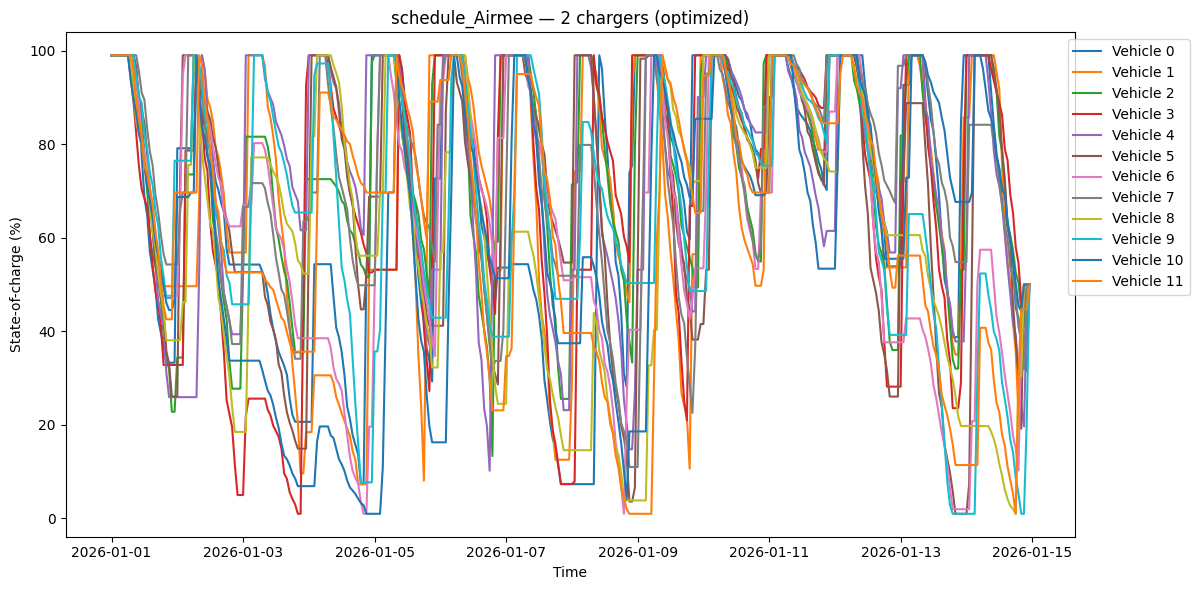

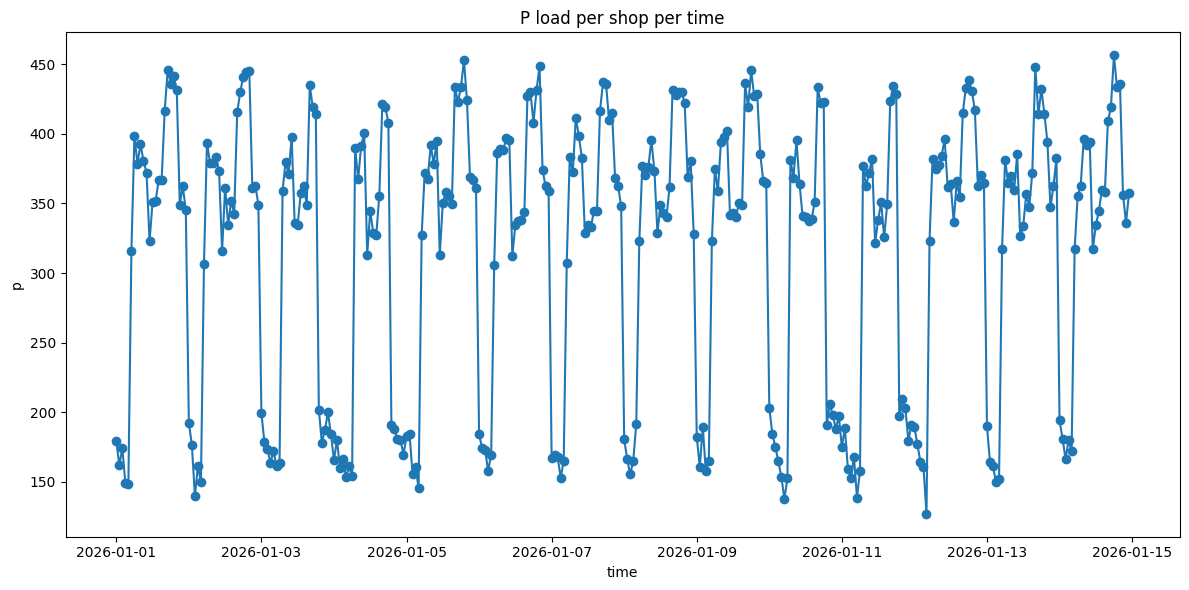

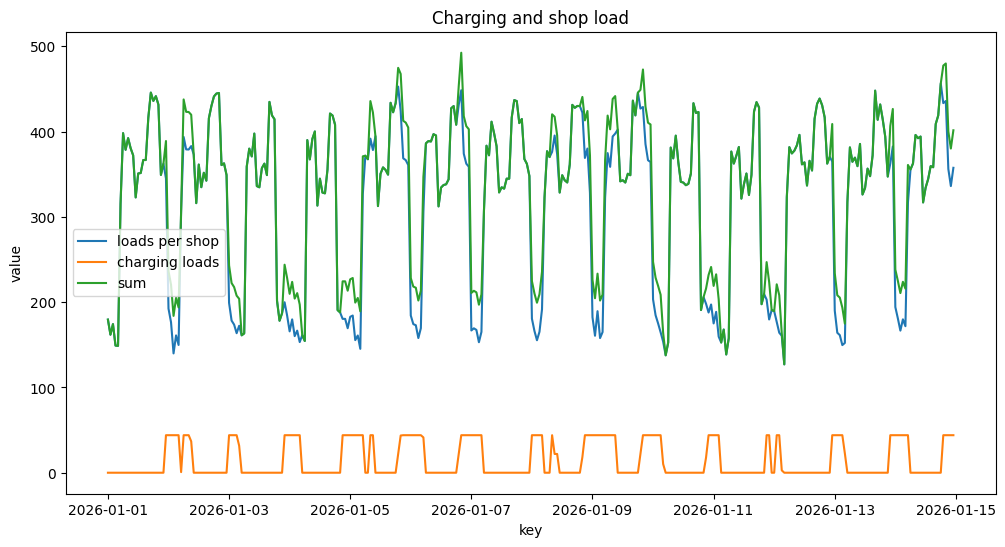


Processing schedule_Postnord ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 2 chargers: No value for uninitialized VarData object P[0,1]
  Testing 3 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <c

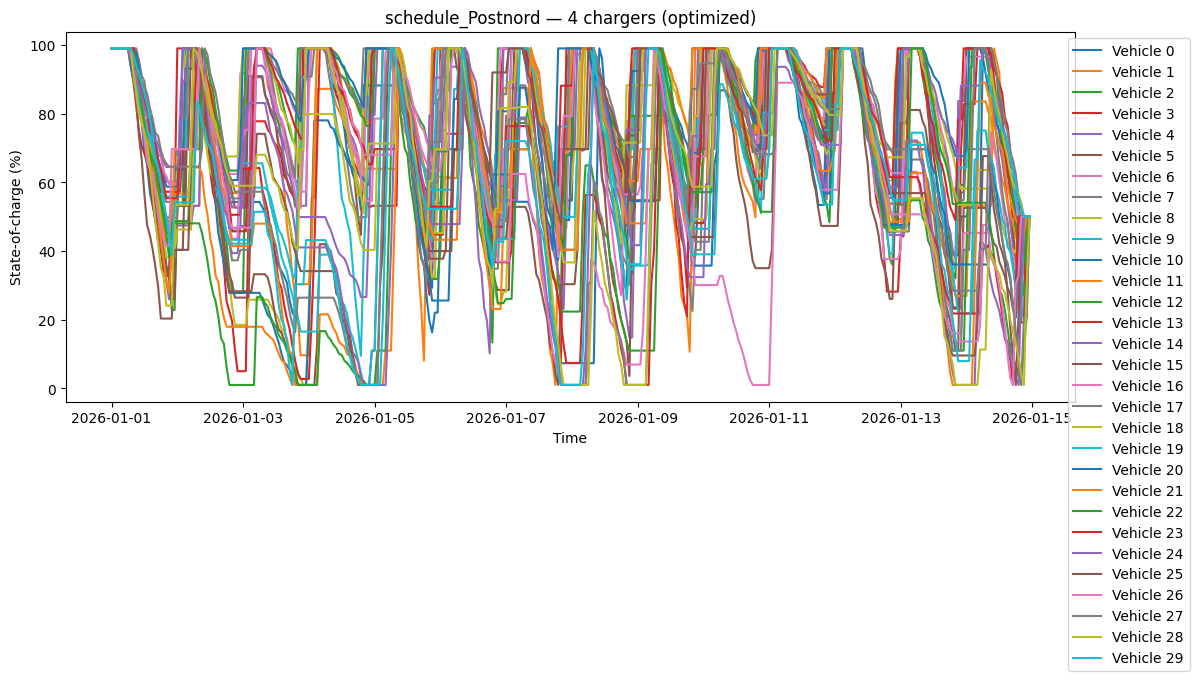

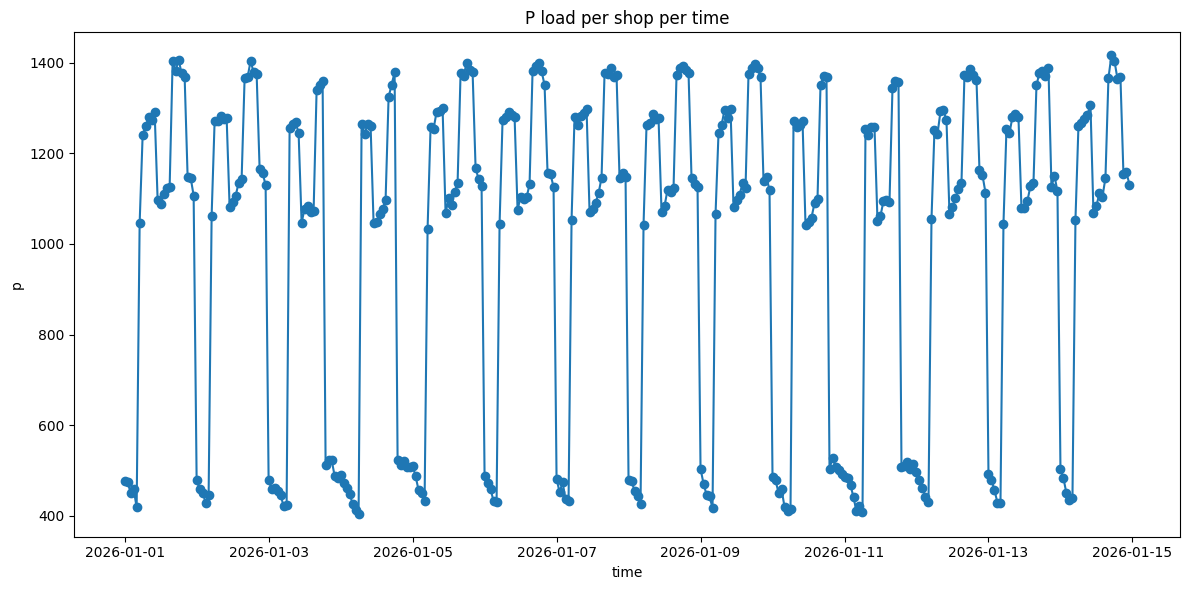

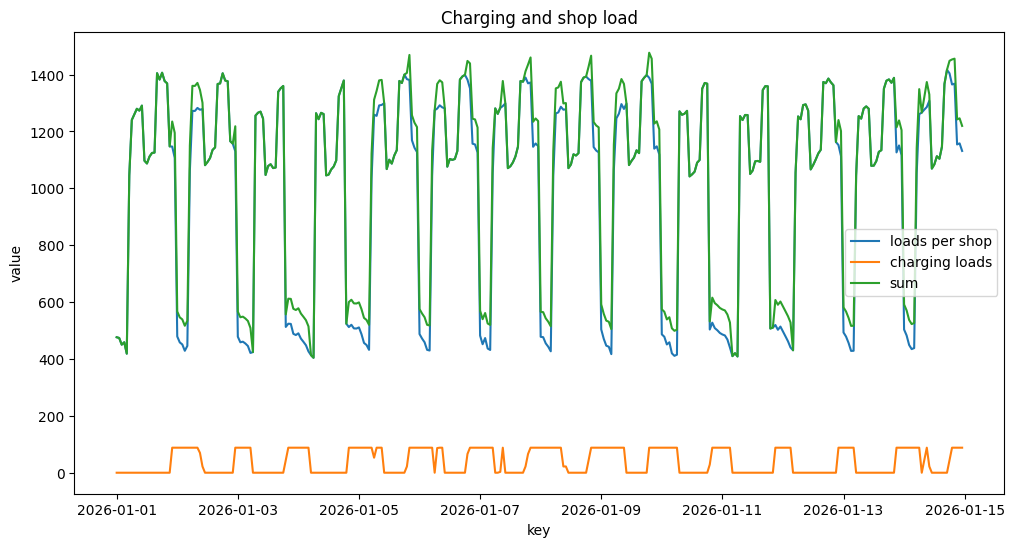


Processing schedule_Mathem ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
   ✅ Feasible with 2 chargers, cost = 107.00 €
  -> Minimum chargers required: 2


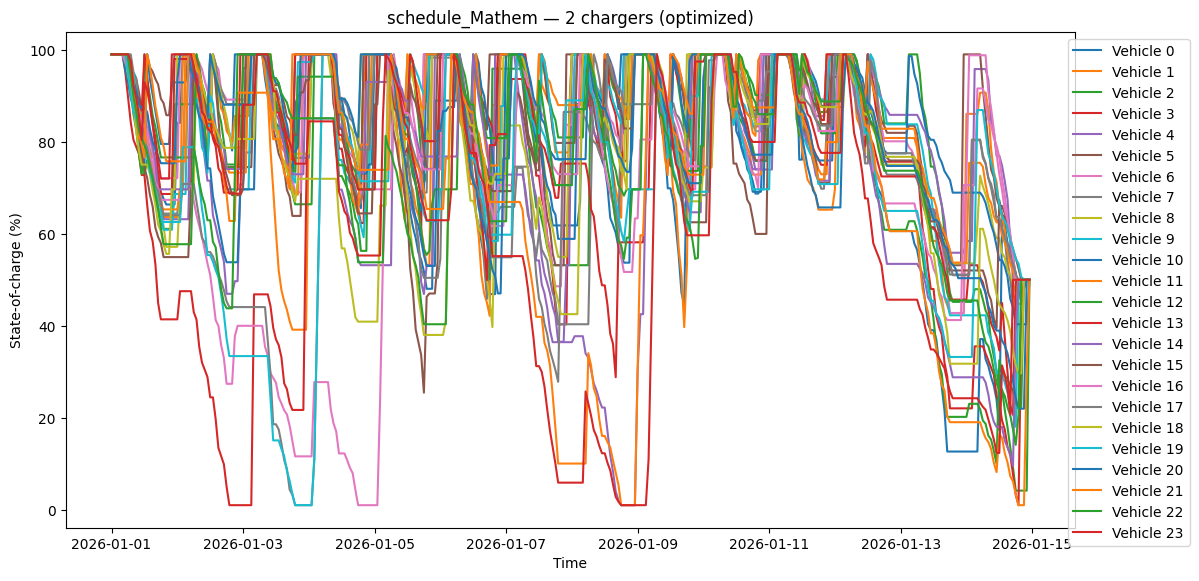

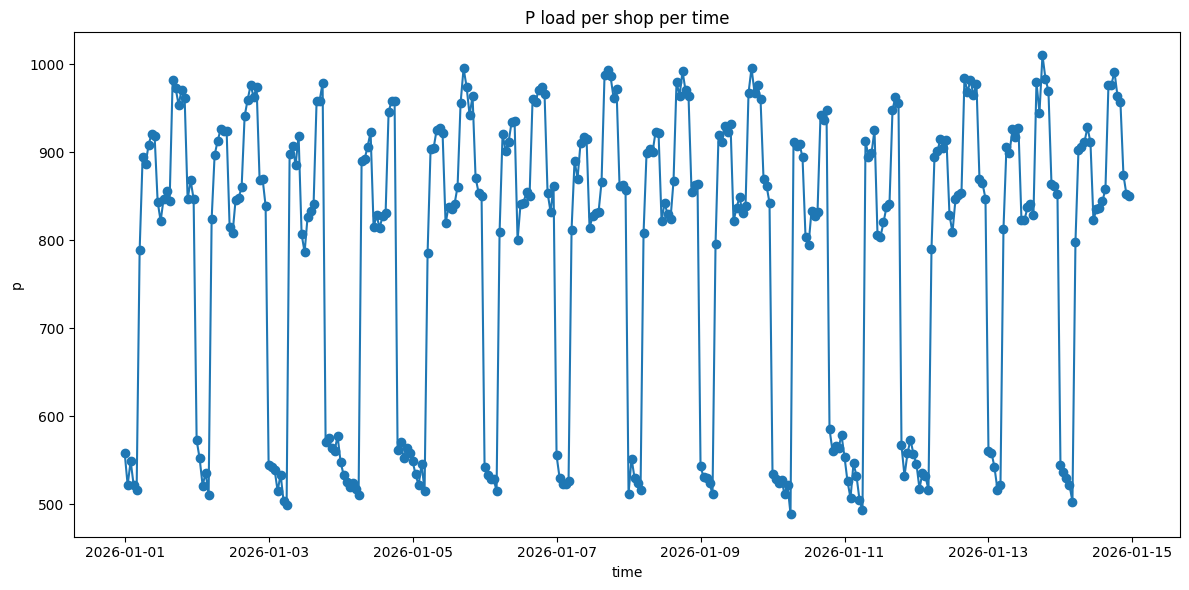

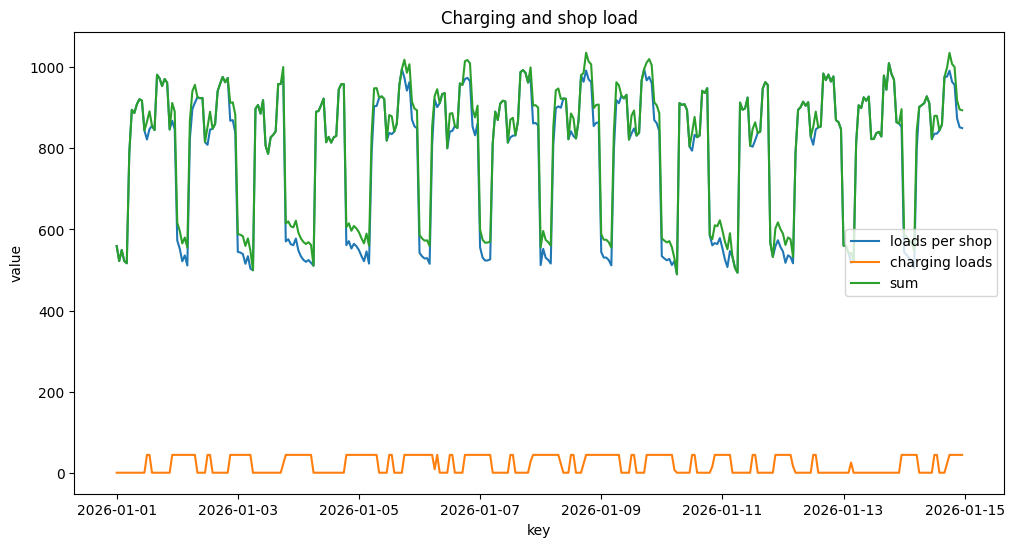


Processing schedule_ICA ...
  Testing 1 chargers ...
   ✅ Feasible with 1 chargers, cost = 64.64 €
  -> Minimum chargers required: 1


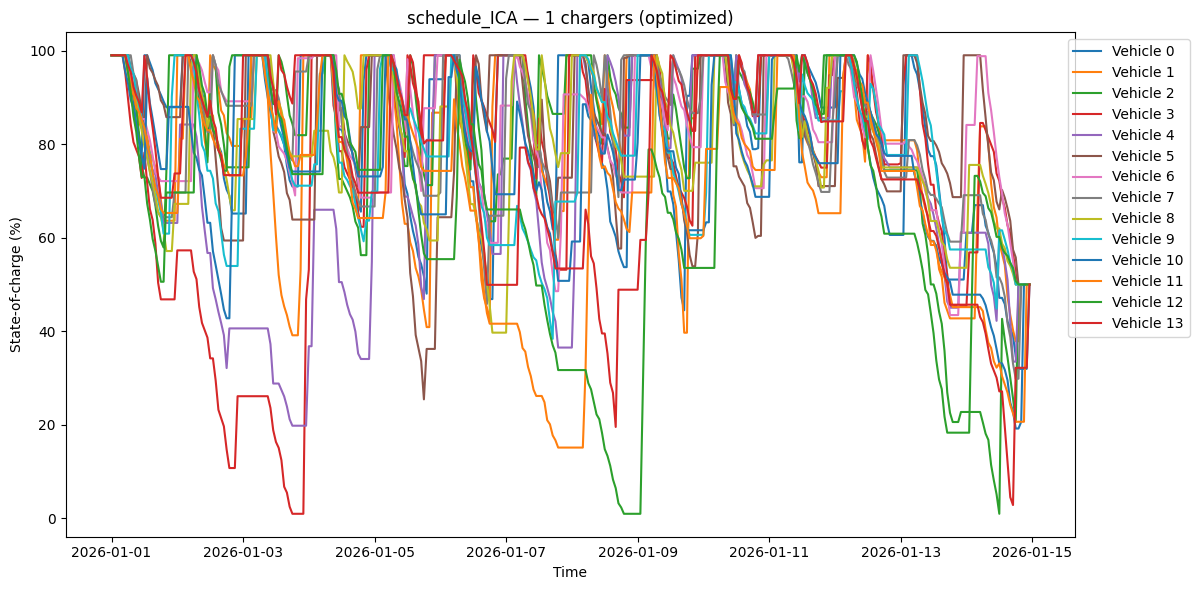

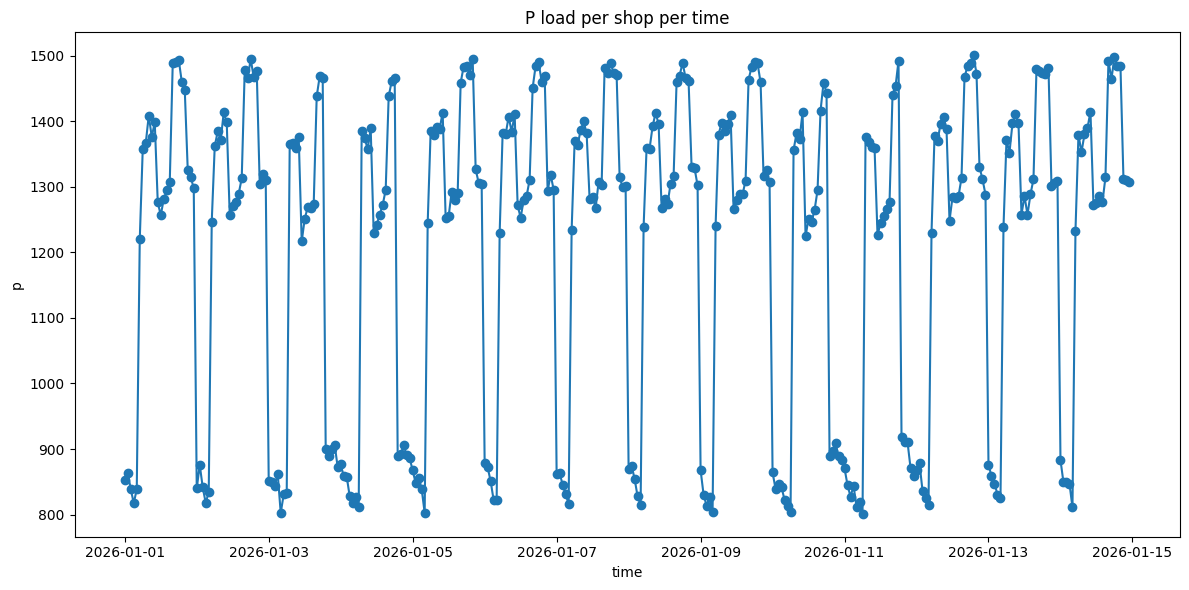

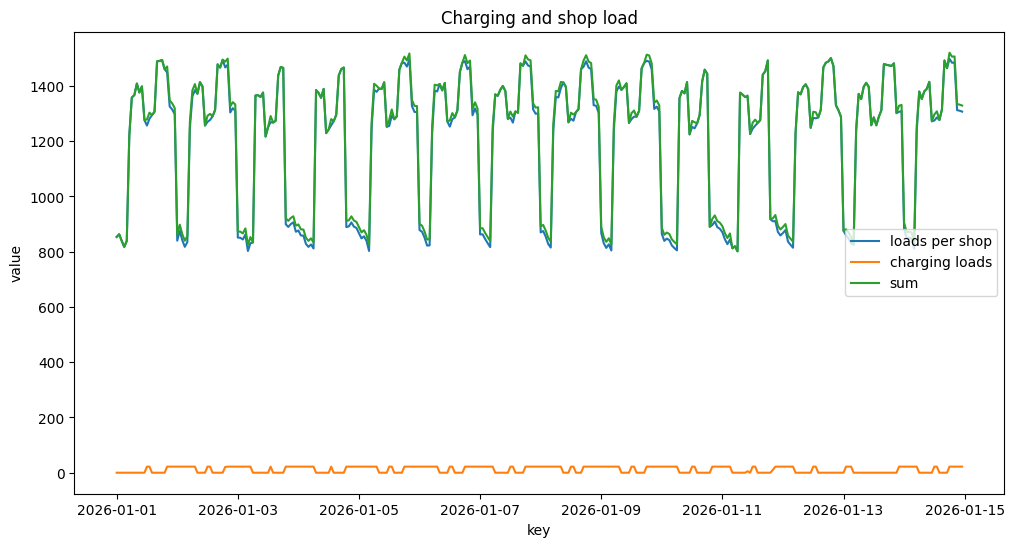


Optimization Summary:
 schedule_Airmee: 2 chargers (reason=ok)
 schedule_Postnord: 4 chargers (reason=ok)
 schedule_Mathem: 2 chargers (reason=ok)
 schedule_ICA: 1 chargers (reason=ok)

PHASE 2: NETWORK POWER FLOW SIMULATION

Running power flow simulations...
Progress: 2026-01-01 00:00:00
Progress: 2026-01-02 00:00:00
Progress: 2026-01-03 00:00:00
Progress: 2026-01-04 00:00:00
Progress: 2026-01-05 00:00:00
Progress: 2026-01-06 00:00:00
Progress: 2026-01-07 00:00:00
Progress: 2026-01-08 00:00:00
Progress: 2026-01-09 00:00:00
Progress: 2026-01-10 00:00:00
Progress: 2026-01-11 00:00:00
Progress: 2026-01-12 00:00:00
Progress: 2026-01-13 00:00:00
Progress: 2026-01-14 00:00:00

Total losses: 65.2638 MW
Peak load: 26.8322 MW at 2026-01-05 20:00:00
Average load: 25.7729 MW
Load factor: 0.9605

Lines and trafos violating limits (>100% loading):
  None

Buses violating voltage limits (1.1/0.9 pu):
  None

PHASE 3: N-1 CONTINGENCY ANALYSIS (with detailed logging)
Contingencies per timestamp: 15


NameError: name 'violation_summary' is not defined

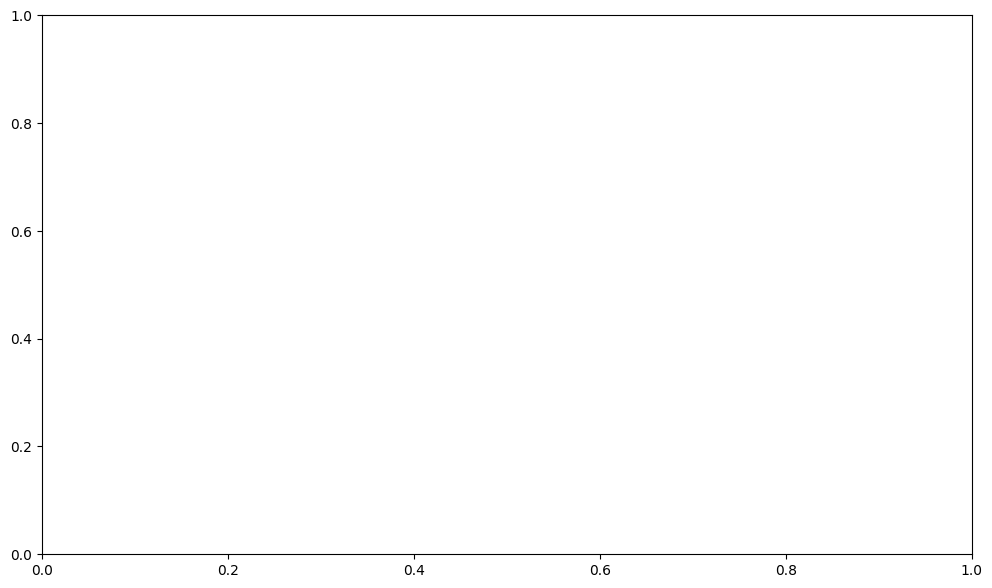

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import timedelta
import math
import csv
import copy

# Pyomo imports
from pyomo.environ import (
    ConcreteModel, Var, Set, Param, Objective, Constraint, NonNegativeReals,
    Reals, SolverFactory, value, summation
)

import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top
import networkx as nx

# -------------------------
# Config / mappings
# -------------------------
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}
SOC_max_percentage = 0.99
SOC_min_percentage = 0.01
SOC_last_time_step_percentage = 0.5
FAST_AC_CAPACITY_KW = 22.0

# Load freight profiles
file_path_loads = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path_loads)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
).dt.tz_localize(None)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]

# -------------------------
# Core optimizer function
# -------------------------
def optimize_shop_energy_cost(file_path,
                              n_chargers,
                              price_series,
                              solver_name='glpk',
                              verbose=False):
    """
    Build and solve a Pyomo LP that minimizes energy cost for charging
    with a fixed number of chargers.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    df = pd.read_csv(file_path)
    if 'date' not in df.columns:
        raise ValueError("CSV must have a 'date' column with timestamps.")
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    time_index = sorted(df['date'].unique())
    T = len(time_index)
    if T < 1:
        raise ValueError("No timestamps found in file.")

    time_to_idx = {ts: idx+1 for idx, ts in enumerate(time_index)}
    idx_to_time = {idx+1: ts for idx, ts in enumerate(time_index)}

    delta_hours = {}
    for idx in range(1, T+1):
        if idx == 1:
            if T >= 2:
                dt = (idx_to_time[2] - idx_to_time[1]).total_seconds() / 3600.0
            else:
                dt = 1.0
        else:
            dt = (idx_to_time[idx] - idx_to_time[idx-1]).total_seconds() / 3600.0
        if dt <= 0:
            dt = 1.0
        delta_hours[idx] = dt

    vehicles = sorted(df['VehicleID'].unique())
    if len(vehicles) == 0:
        raise ValueError("No vehicles found in the schedule CSV.")

    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    Pmax_by_vehicle = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW)
                       for vid in vehicles}
    Cap_by_vehicle = {vid: battery_capacities.get(vehicle_types.get(vid), 48.0)
                      for vid in vehicles}

    idx_cols = ['VehicleID', 'date']
    agg = df.groupby(idx_cols).agg({
        'Consumption_kWh': 'sum',
        'Location': 'max'
    }).reset_index()

    E_drive = {(vid, t): 0.0 for vid in vehicles for t in range(1, T+1)}
    I_at_depot = {(vid, t): 0 for vid in vehicles for t in range(1, T+1)}

    for _, row in agg.iterrows():
        vid = row['VehicleID']
        ts = row['date']
        idx = time_to_idx[ts]
        E_drive[(vid, idx)] = float(row.get('Consumption_kWh', 0.0))
        I_at_depot[(vid, idx)] = 1 if int(row.get('Location', 0)) == 1 else 0

    if price_series is None:
        flat_price = 0.20
        price_by_idx = {t: flat_price for t in range(1, T+1)}
    else:
        ps = price_series.copy()
        ps.index = pd.to_datetime(ps.index, format='%d.%m.%Y %H:%M')
        price_by_idx = {}
        for idx in range(1, T+1):
            try:
                ts = idx_to_time[idx]
                price_by_idx[idx] = ps.iloc[idx-1]
            except:
                raise ValueError("error in creating price indexes")

    model = ConcreteModel()

    model.VEH = Set(initialize=vehicles, ordered=True)
    model.TIME = Set(initialize=list(range(1, T+1)), ordered=True)

    model.Cap = Param(model.VEH, initialize=Cap_by_vehicle, within=Reals)
    model.PmaxVeh = Param(model.VEH, initialize=Pmax_by_vehicle, within=Reals)
    model.Edrive = Param(model.VEH, model.TIME, initialize=E_drive, within=Reals)
    model.Avail = Param(model.VEH, model.TIME, initialize=I_at_depot, within=Reals)
    model.dt = Param(model.TIME, initialize=delta_hours, within=Reals)
    model.price = Param(model.TIME, initialize=price_by_idx, within=Reals)
    model.n_chargers = Param(initialize=int(n_chargers))
    model.P_charger = Param(initialize=float(FAST_AC_CAPACITY_KW))
    model.SOC_max_percentage = Param(initialize=SOC_max_percentage)
    model.SOC_min_percentage = Param(initialize=SOC_min_percentage)
    model.Time_steps_amount = Param(initialize=T)
    model.SOC_last_time_step_percentage = Param(initialize=SOC_last_time_step_percentage)

    model.P = Var(model.VEH, model.TIME, domain=NonNegativeReals)
    model.SOC = Var(model.VEH, model.TIME, domain=NonNegativeReals)

    def obj_rule(m):
        return sum(m.price[t] * m.P[v, t] * m.dt[t] for v in m.VEH for t in m.TIME)
    model.obj = Objective(rule=obj_rule, sense=1)

    def p_max_rule(m, v, t):
        return m.P[v, t] <= m.Avail[v, t] * m.PmaxVeh[v]
    model.p_max_con = Constraint(model.VEH, model.TIME, rule=p_max_rule)

    def charger_cap_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) <= m.n_chargers * m.P_charger
    model.charger_cap_con = Constraint(model.TIME, rule=charger_cap_rule)

    def charger_cap_rule_unique(m, v, t):
        return m.P[v, t] <= m.P_charger
    model.charger_cap_con_uniq = Constraint(model.VEH, model.TIME, rule=charger_cap_rule_unique)

    def soc_first_rule(m, v):
        t = 1
        return m.SOC[v, t] == m.Cap[v] * m.SOC_max_percentage - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_first_con = Constraint(model.VEH, rule=soc_first_rule)

    def soc_evol_rule(m, v, t):
        if t == 1:
            return Constraint.Skip
        return m.SOC[v, t] == m.SOC[v, t-1] - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_evol_con = Constraint(model.VEH, model.TIME, rule=soc_evol_rule)

    def soc_ub_rule(m, v, t):
        return m.SOC[v, t] <= m.Cap[v] * m.SOC_max_percentage
    model.soc_ub_con = Constraint(model.VEH, model.TIME, rule=soc_ub_rule)

    def soc_lb_rule(m, v, t):
        return m.SOC[v, t] >= m.Cap[v] * m.SOC_min_percentage
    model.soc_lb_con = Constraint(model.VEH, model.TIME, rule=soc_lb_rule)

    def soc_end_rule(m, v):
        t = m.Time_steps_amount
        return m.SOC[v, t] == m.Cap[v] * m.SOC_last_time_step_percentage
    model.soc_end_con = Constraint(model.VEH, rule=soc_end_rule)

    solver = None
    solver_try_order = [solver_name, 'cbc', 'glpk'] if solver_name != 'glpk' else ['glpk', 'cbc']
    solver_available = False
    last_solver_err = None
    for sname in solver_try_order:
        try:
            solver = SolverFactory(sname)
            if solver is None:
                continue
            res = solver.solve(model, tee=verbose)
            solver_available = True
            break
        except Exception as e:
            last_solver_err = e
            solver = None
            continue

    if not solver_available:
        raise RuntimeError(f"No solver available/working. Tried {solver_try_order}. "
                           f"Last error: {last_solver_err}")

    obj_val = value(model.obj) / 1000

    P_sol = {}
    P_per_time = {}
    SOC_traces = {v: [] for v in vehicles}
    SOC_traces_percentage = {v: [] for v in vehicles}
    for t in model.TIME:
        all_P = 0.0
        for v in model.VEH:
            P_sol[(v, idx_to_time[t])] = float(value(model.P[v, t]))
            all_P += float(value(model.P[v, t]))
        P_per_time[idx_to_time[t]] = all_P

    for v in vehicles:
        for t in model.TIME:
            SOC_traces[v].append(float(value(model.SOC[v, t])))
            SOC_traces_percentage[v].append(float(value(model.SOC[v, t] / model.Cap[v])))

    n_vehicles = len(vehicles)
    if n_chargers > n_vehicles:
        raise RuntimeError(f"No feasible solution found, number of chargers {n_chargers} would be higher than number of vehicles {n_vehicles}")

    result = {
        'status': str(res.solver.termination_condition) if hasattr(res, 'solver') else 'unknown',
        'objective': obj_val,
        'P': P_sol,
        'P_time': P_per_time,
        'SOC': SOC_traces,
        'time_index': [idx_to_time[t] for t in model.TIME],
        'n_chargers': int(n_chargers),
        'solver': solver,
        'SOC_percentage': SOC_traces_percentage
    }

    return result

# -------------------------
# Plotting helper
# -------------------------
def plot_soc_from_result(result, shop, title=None, save_fig=False, out_path=None):
    time = result['time_index']
    soc_percentage = result['SOC_percentage']
    p_shop = result['P_time']

    plt.figure(figsize=(12, 6))
    for vid, series in soc_percentage.items():
        series_pct = [s * 100.0 for s in series]
        plt.plot(time, series_pct, label=f"Vehicle {vid}")

    plt.xlabel("Time")
    plt.ylabel("State-of-charge (%)")
    if title is None:
        title = f"SOC over time — {result.get('n_chargers', '?')} chargers"
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        if out_path is None:
            out_path = Path("soc_plot.png")
        plt.savefig(out_path, dpi=150)
        print("Saved figure to", out_path)
    plt.show()

    shop_name = shop.split("_")[1]
    shop_loads = load_profile[shop_name]
    shop_loads = shop_loads.to_dict()

    plt.figure(figsize=(12, 6))
    xs, ys = zip(*sorted(shop_loads.items()))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("time")
    plt.ylabel("p")
    plt.title("P load per shop per time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    x = sorted(shop_loads.keys())
    y1 = [shop_loads[k] for k in x]
    y2 = [p_shop[k] for k in x]
    y3 = [p_shop[k] + shop_loads[k] for k in x]

    plt.plot(x, y1, label="loads per shop")
    plt.plot(x, y2, label="charging loads")
    plt.plot(x, y3, label="sum")
    plt.legend()
    plt.xlabel("key")
    plt.ylabel("value")
    plt.title("Charging and shop load")
    plt.show()

def open_price_file():
    prices = {}
    date_format = '%d.%m.%Y %H:%M'

    with open("Prices.csv", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader, None)
        for row in reader:
            from_time = row[0].split(" - ")[0]
            prices[from_time] = float(row[1])
    prices_pd = pd.Series(prices)
    return prices_pd

# -------------------------
# OPTIMIZATION PHASE
# -------------------------
shop_optimized_charging_schedules = {}

base_path = Path(os.getcwd()).parent / "data" / "Output"
shops_schedule = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

results = {}
MAX_CHARGERS_TO_TEST = 29

print("="*60)
print("PHASE 1: EV CHARGING OPTIMIZATION")
print("="*60)

for shop in shops_schedule:
    shop_folder = base_path / shop
    file = shop_folder / f"{shop}.csv"
    if not file.exists():
        print(f"[WARN] file not found: {file}")
        results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
        continue

    print(f"\nProcessing {shop} ...")

    found = False
    best_trace = None
    best_cost = None
    prices = open_price_file()
    for n_ch in range(1, MAX_CHARGERS_TO_TEST, 1):
        print(f"  Testing {n_ch} chargers ...")
        try:
            res = optimize_shop_energy_cost(file, n_chargers=n_ch, price_series=prices, solver_name='glpk', verbose=False)
        except Exception as e:
            print(f"   Solver failed for {n_ch} chargers: {e}")
            continue

        feasible = all(all(val >= -1e-6 for val in soc_list) for soc_list in res['SOC'].values())

        if feasible:
            print(f"   ✅ Feasible with {n_ch} chargers, cost = {res['objective']:.2f} €")
            found = True
            best_trace = res
            best_cost = res['objective']
            best_trace_percentage = res['SOC_percentage']
            shop_name = shop.replace("schedule_", "")
            shop_optimized_charging_schedules[shop_name] = res["P_time"]
            break
        else:
            print(f"   ❌ Infeasible with {n_ch} chargers (battery empty at some point)")

    if found:
        print(f"  -> Minimum chargers required: {n_ch}")
        results[shop] = {
            'min_chargers': n_ch,
            'objective': best_cost,
            'trace': best_trace,
            'trace_percentage': best_trace['SOC_percentage']
        }
        df = pd.read_csv(file)
        vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

        plot_soc_from_result(best_trace, shop, title=f"{shop} — {n_ch} chargers (optimized)", save_fig=False)
    else:
        print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
        results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}

print("\nOptimization Summary:")
for shop, info in results.items():
    print(f" {shop}: {info.get('min_chargers')} chargers (reason={info.get('reason','ok')})")

# -------------------------
# PHASE 2: NETWORK SIMULATION
# -------------------------
print("\n" + "="*60)
print("PHASE 2: NETWORK POWER FLOW SIMULATION")
print("="*60)

# Create network
net0 = nw.create_cigre_network_mv(with_der=False)
net0.switch["closed"] = True
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0
base_loads = net0.load['p_mw'].copy()

# Shop placements
shop_to_bus = {
    "ICA": 13,
    "Mathem": 6,
    "Postnord": 10,
    "Airmee": 6,
}

# Function to create network with shop loads
def create_network_with_shops(net_base, shop_mapping, timestamp, charging_loads):
    net = copy.deepcopy(net_base)
    net.load['p_mw'] = base_loads.copy()

    for shop, bus in shop_mapping.items():
        charging_load_shop = charging_loads[shop]
        if bus is not None:
            existing_loads = net.load[net.load.bus == bus]

            if not existing_loads.empty:
                load_idx = existing_loads.index[0]
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_freight
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_charging
            else:
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                add_mw = add_mw_charging + add_mw_freight
                pp.create_load(net, bus=bus, p_mw=add_mw, q_mvar=0)

    return net

# Run final simulation with all shops
print("\nRunning power flow simulations...")

line_indices = list(net0.line.index)
col_names = [f"line_{i}" for i in line_indices]
res_lines_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)
res_lines_final_loading = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

trafo_indices = list(net0.trafo.index)
col_names = [f"trafo_{i}" for i in trafo_indices]
res_trafo_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)
res_trafo_final_loading = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

bus_indices = list(net0.bus.index)
col_names = [f"bus_{i}" for i in bus_indices]
res_bus_final_voltage = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

peak_load = 0.0
peak_load_ts = None
sum_all_loads = 0.0
all_losses = 0.0
all_nets = {}

for ts_idx, ts in enumerate(load_profile.index):
    if ts_idx % 24 == 0:
        print(f"Progress: {ts}")

    net_final = create_network_with_shops(net0, shop_to_bus, ts, shop_optimized_charging_schedules)
    all_nets[ts] = net_final

    try:
        pp.runpp(net_final, calculate_voltage_angles=False)
        line_loading = net_final.res_line.loading_percent
        line_losses = net_final.res_line.pl_mw
        trafo_loading = net_final.res_trafo.loading_percent
        bus_voltage = net_final.res_bus.vm_pu

        for li in line_indices:
            res_lines_final_losses.at[ts, f"line_{li}"] = line_losses.at[li]
            all_losses += line_losses.at[li]
            res_lines_final_loading.at[ts, f"line_{li}"] = line_loading.at[li]

        trafo_losses = net_final.res_trafo.pl_mw
        for tr in trafo_indices:
            res_trafo_final_losses.at[ts, f"trafo_{tr}"] = trafo_losses.at[tr]
            all_losses += trafo_losses.at[tr]
            res_trafo_final_loading.at[ts, f"trafo_{tr}"] = trafo_loading.at[tr]

        for bs in bus_indices:
            res_bus_final_voltage.at[ts, f"bus_{bs}"] = bus_voltage.at[bs]

        all_load_ts = net_final.load['p_mw'].sum()
        if all_load_ts > peak_load:
            peak_load = all_load_ts
            peak_load_ts = ts

        sum_all_loads += all_load_ts

    except Exception as e:
        print(f"Power flow failed at {ts}: {e}")

print(f"\nTotal losses: {all_losses:.4f} MW")
print(f"Peak load: {peak_load:.4f} MW at {peak_load_ts}")
average_load = sum_all_loads / 336
print(f"Average load: {average_load:.4f} MW")
load_factor = average_load / peak_load
print(f"Load factor: {load_factor:.4f}")

print("\nLines and trafos violating limits (>100% loading):")
violations_found = False
for ts_idx, ts in enumerate(load_profile.index):
    for li in line_indices:
        line_loading = res_lines_final_loading.at[ts, f"line_{li}"]
        if line_loading > 100:
            print(f"  line_{li}: {line_loading:.2f}% at {ts}")
            violations_found = True

for ts_idx, ts in enumerate(load_profile.index):
    for tr in trafo_indices:
        trafo_loading = res_trafo_final_loading.at[ts, f"trafo_{tr}"]
        if trafo_loading > 100:
            print(f"  trafo_{tr}: {trafo_loading:.2f}% at {ts}")
            violations_found = True

if not violations_found:
    print("  None")

print("\nBuses violating voltage limits (1.1/0.9 pu):")
violations_found = False
for ts_idx, ts in enumerate(load_profile.index):
    for bs in bus_indices:
        bus_voltage = res_bus_final_voltage.at[ts, f"bus_{bs}"]
        if bus_voltage > 1.1 or bus_voltage < 0.9:
            print(f"  bus_{bs}: {bus_voltage:.4f} pu at {ts}")
            violations_found = True

if not violations_found:
    print("  None")
# -------------------------
# PHASE 3: N-1 CONTINGENCY ANALYSIS (improved, with logging)
# -------------------------
print("\n" + "="*60)
print("PHASE 3: N-1 CONTINGENCY ANALYSIS (with detailed logging)")
print("="*60)

# Prepare containers
violation_rows = []  # will collect dicts: ts, out_element, category, element_id, value
critical_counts = {}  # keyed by (element_type, element_id) -> count

# make sure we test actual line indices (or a subset if you intentionally want 12 specific)
line_indices_all = list(net0.line.index)  # all lines in base network
# If you really want to test only first 12 element indices, use:
# line_indices_to_test = line_indices_all[:12]
line_indices_to_test = line_indices_all  # test all lines by default

n_tests_per_ts = len(line_indices_to_test)
print(f"Contingencies per timestamp: {n_tests_per_ts}")

for ts_idx, ts in enumerate(load_profile.index):
    if ts_idx % 48 == 0:
        print(f"Progress: {ts_idx}/{len(load_profile.index)} timesteps")

    # restore the network snapshot for this timestamp
    net = copy.deepcopy(all_nets[ts])

    # loop through *actual* lines to take out of service
    for out_line in line_indices_to_test:
        # take the chosen line out
        if out_line not in net.line.index:
            # defensive: skip unexpected indices
            continue

        net.line.at[out_line, "in_service"] = False
        net.switch["closed"] = True

        # optional: re-evaluate topology switches to maintain radiality/minimum spanning tree
        try:
            G = top.create_nxgraph(net, respect_switches=True)
            mst = nx.minimum_spanning_tree(G)
            for j, sw in net.switch.iterrows():
                b1 = sw.bus
                if sw.et == "l":
                    # find the "other bus" of the referenced line (element)
                    elem_idx = int(sw.element)
                    from_bus = net.line.at[elem_idx, "from_bus"]
                    to_bus = net.line.at[elem_idx, "to_bus"]
                    other_bus = from_bus if to_bus == b1 else to_bus
                    if not mst.has_edge(b1, other_bus):
                        net.switch.at[j, "closed"] = False
        except Exception:
            # continue even if topology trimming fails
            pass

        try:
            pp.runpp(net, calculate_voltage_angles=False)

            # ---- lines ----
            for line_id, loading in net.res_line.loading_percent.items():
                if loading is None:
                    continue
                if loading > 100:
                    violation_rows.append({
                        'timestamp': ts,
                        'out_element_type': 'line',
                        'out_element_id': out_line,
                        'category': 'Line Loading',
                        'element_id': int(line_id),
                        'value': float(loading)
                    })
                    critical_counts.setdefault(('line', int(line_id)), 0)
                    critical_counts[('line', int(line_id))] += 1

            # ---- trafos ----
            for trafo_id, loading in net.res_trafo.loading_percent.items():
                if loading is None:
                    continue
                if loading > 100:
                    violation_rows.append({
                        'timestamp': ts,
                        'out_element_type': 'line',
                        'out_element_id': out_line,
                        'category': 'Trafo Loading',
                        'element_id': int(trafo_id),
                        'value': float(loading)
                    })
                    critical_counts.setdefault(('trafo', int(trafo_id)), 0)
                    critical_counts[('trafo', int(trafo_id))] += 1

            # ---- bus voltages (choose the thresholds you want) ----
            # Example: record both thresholds but flag them separately
            for bus_id, v in net.res_bus.vm_pu.items():
                if v is None:
                    continue
                if (v > 1.1) or (v < 0.9):
                    violation_rows.append({
                        'timestamp': ts,
                        'out_element_type': 'line',
                        'out_element_id': out_line,
                        'category': 'Bus Voltage (1.05/0.95)',
                        'element_id': int(bus_id),
                        'value': float(v)
                    })
                    critical_counts.setdefault(('bus_105', int(bus_id)), 0)
                    critical_counts[('bus_105', int(bus_id))] += 1
                if (v > 1.05) or (v < 0.95):
                    violation_rows.append({
                        'timestamp': ts,
                        'out_element_type': 'line',
                        'out_element_id': out_line,
                        'category': 'Bus Voltage (1.1/0.9)',
                        'element_id': int(bus_id),
                        'value': float(v)
                    })
                    critical_counts.setdefault(('bus_11', int(bus_id)), 0)
                    critical_counts[('bus_11', int(bus_id))] += 1

        except Exception as e:
            # log the failure if you want
            # violation_rows.append({'timestamp': ts, 'out_element_type': 'line', 'out_element_id': out_line, 'category': 'RunPP Failure', 'element_id': None, 'value': str(e)})
            pass

        # restore the line for the next contingency
        net.line.at[out_line, "in_service"] = True

# Build a DataFrame of all violations
violations_df = pd.DataFrame(violation_rows)
print("\nTotal recorded violation rows:", len(violations_df))

# summary tables
if not violations_df.empty:
    summary_by_category = violations_df.groupby('category').size().sort_values(ascending=False)
    summary_by_out = violations_df.groupby('out_element_id').size().sort_values(ascending=False).head(20)
    print("\nTop categories:\n", summary_by_category)
    print("\nTop out-of-service elements (most often causing violations):\n", summary_by_out)

    # top precise offending elements (type+id)
    top_critical = sorted(critical_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop critical elements (type, id) and counts:")
    for (etype, eid), cnt in top_critical:
        print(f"  {etype} {eid}: {cnt} violations")

# Save to csv for inspection
violations_df.to_csv("contingency_violations_detailed.csv", index=False)
print("Saved detailed violations to contingency_violations_detailed.csv")

# -------------------------
# VISUALIZATION
# -------------------------
fig, ax = plt.subplots(figsize=(12, 7))

categories = list(violation_summary.keys())
counts = list(violation_summary.values())
colors = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db']

x_pos = np.arange(len(categories))
bars = ax.bar(x_pos, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85, width=0.6)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(count)}',
               ha='center', va='bottom',
               fontsize=14, fontweight='bold')

ax.set_ylabel('Number of Violations', fontsize=14, fontweight='bold')
ax.set_xlabel('Violation Category', fontsize=14, fontweight='bold')
ax.set_title('N-1 Contingency Violations - Optimized EV Charging Schedule',
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Add summary statistics box
total_violations = sum(counts)
textstr = f'Total Violations: {total_violations}\nSimulation Period: {len(load_profile)} hours\nContingencies Tested: 12 lines'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6, edgecolor='black', linewidth=2)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nTotal violations: {total_violations}")
print(f"Most critical violation category: {max(violation_summary.items(), key=lambda x: x[1])[0].replace(chr(10), ' ')}")

if critical_lines:
    most_critical_line = max(critical_lines.items(), key=lambda x: x[1])
    print(f"Most critical line: Line {most_critical_line[0]} ({most_critical_line[1]} violations)")
else:
    print("No critical lines identified")

PHASE 1: EV CHARGING OPTIMIZATION

Processing schedule_Airmee ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
   ✅ Feasible with 2 chargers, cost = 73.35 €
  -> Minimum chargers required: 2


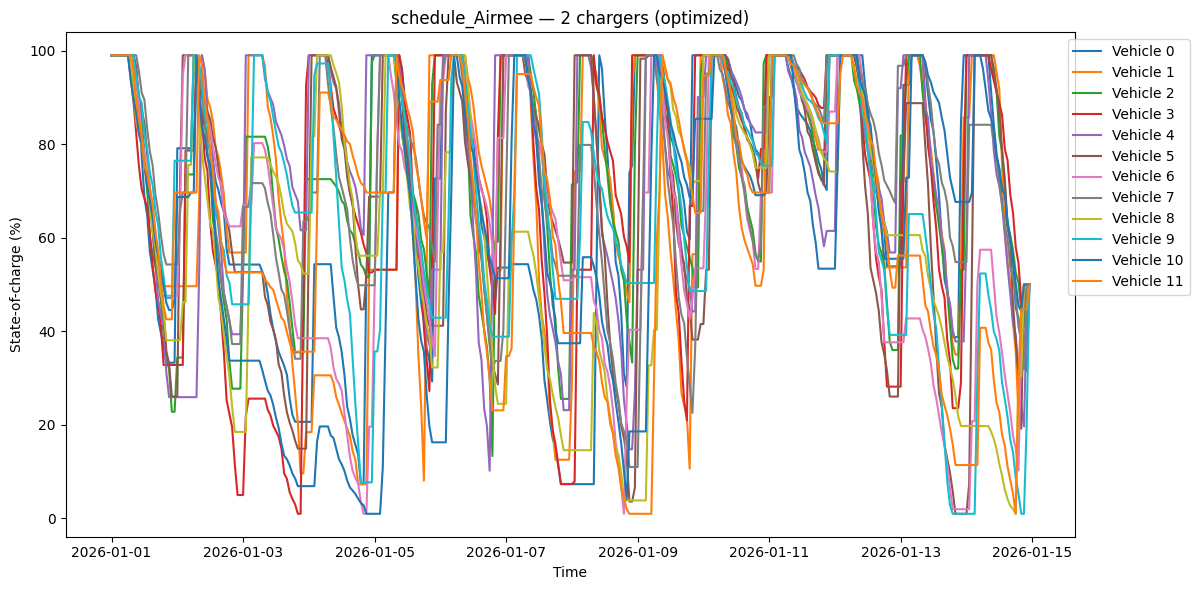

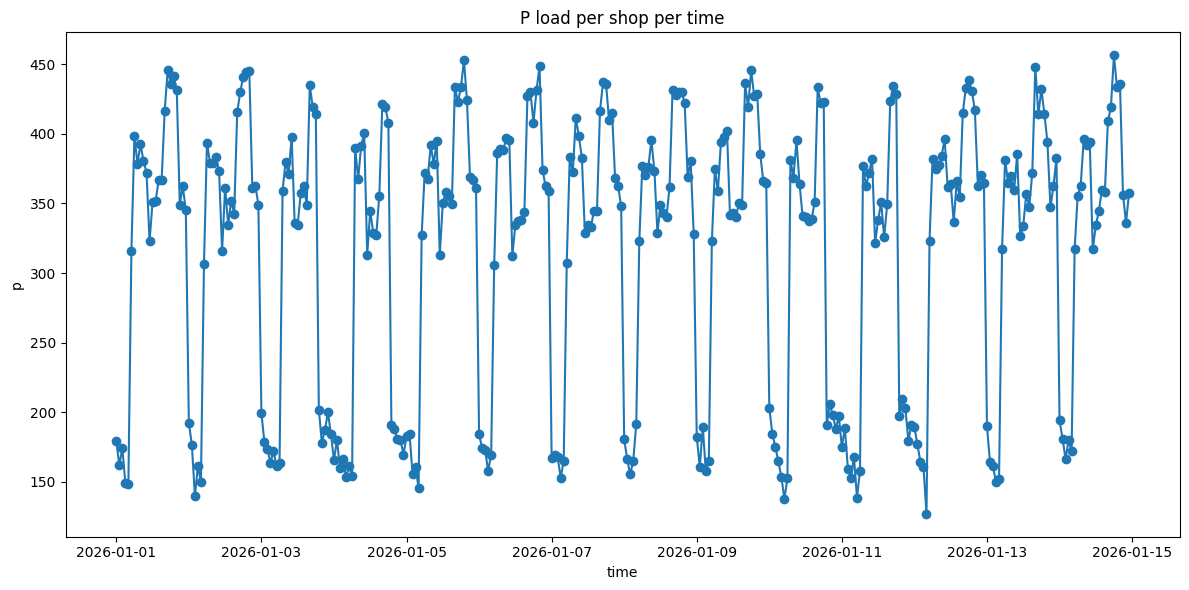

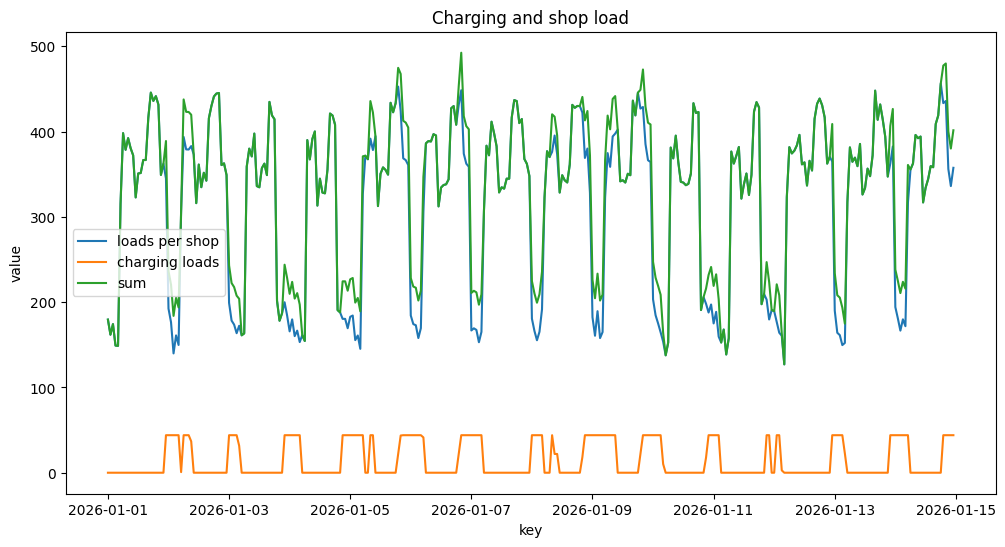


Processing schedule_Postnord ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 2 chargers: No value for uninitialized VarData object P[0,1]
  Testing 3 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <c

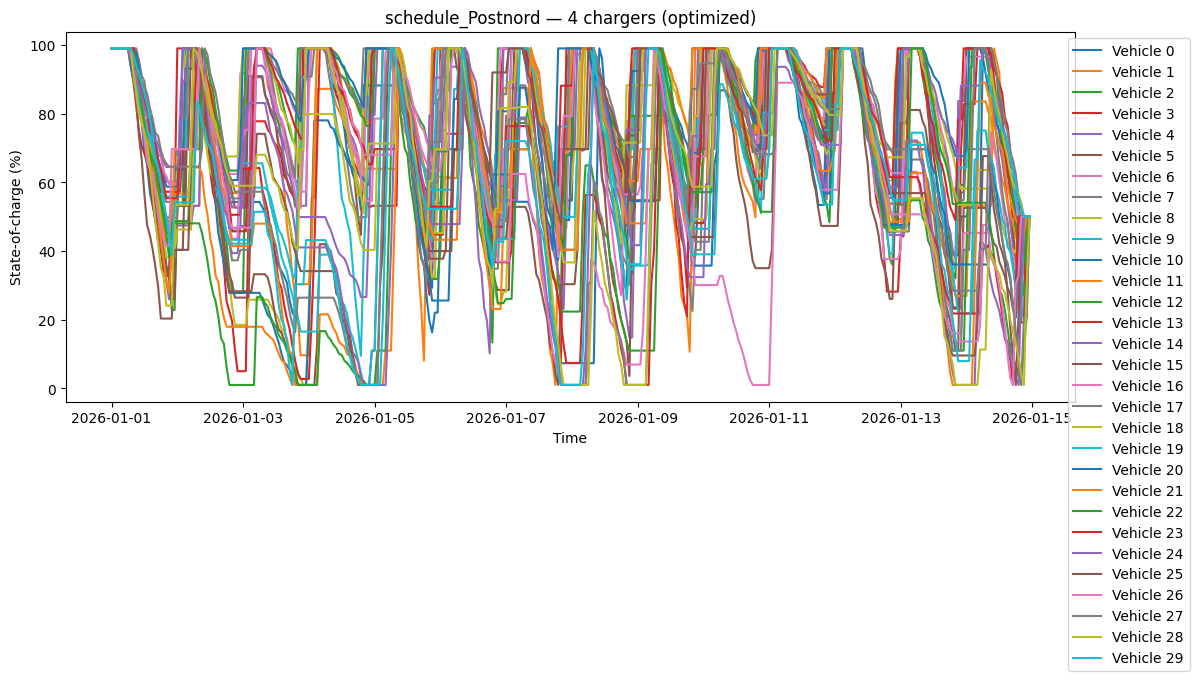

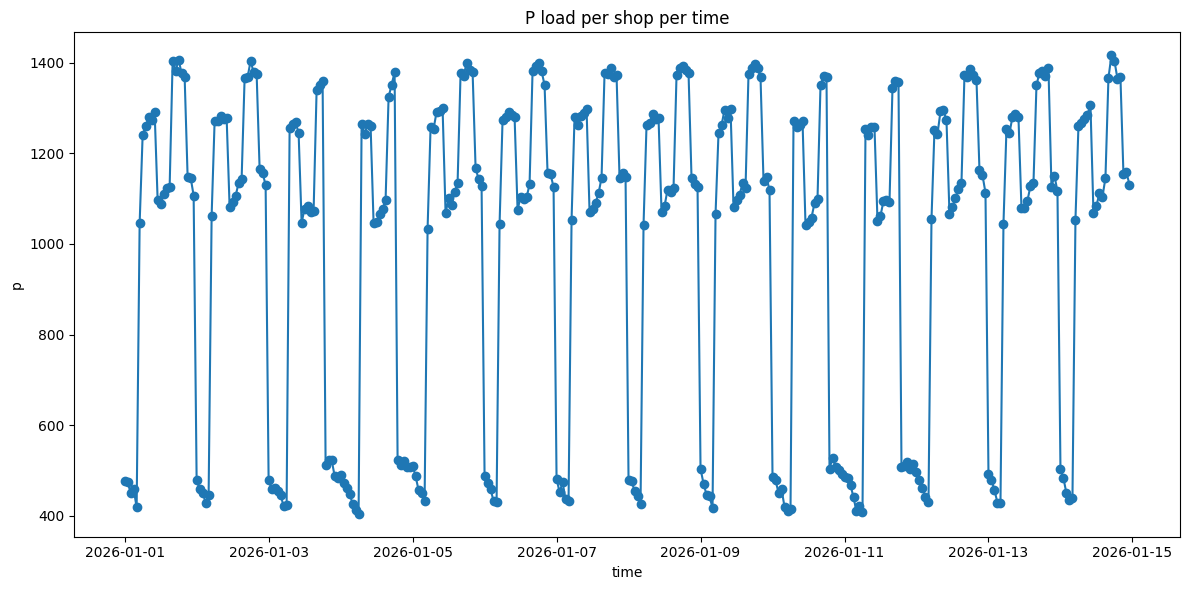

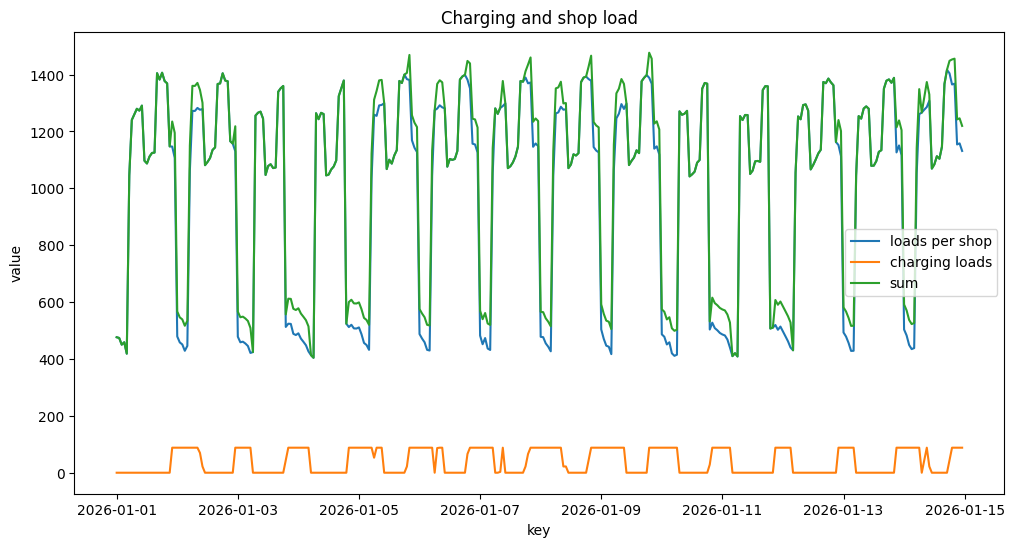


Processing schedule_Mathem ...
  Testing 1 chargers ...
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
   ✅ Feasible with 2 chargers, cost = 107.00 €
  -> Minimum chargers required: 2


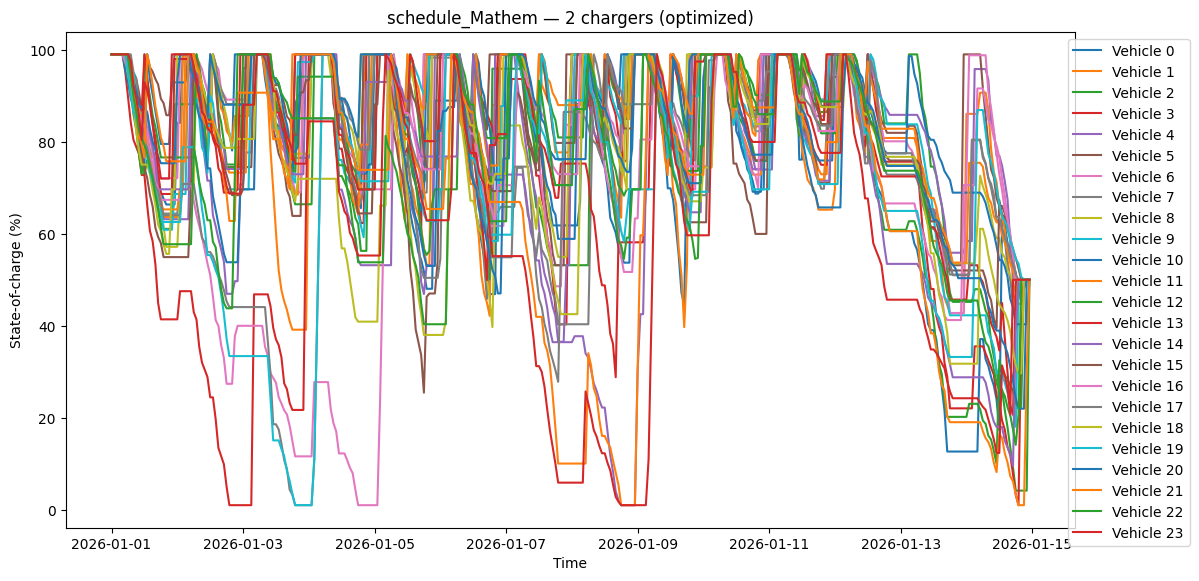

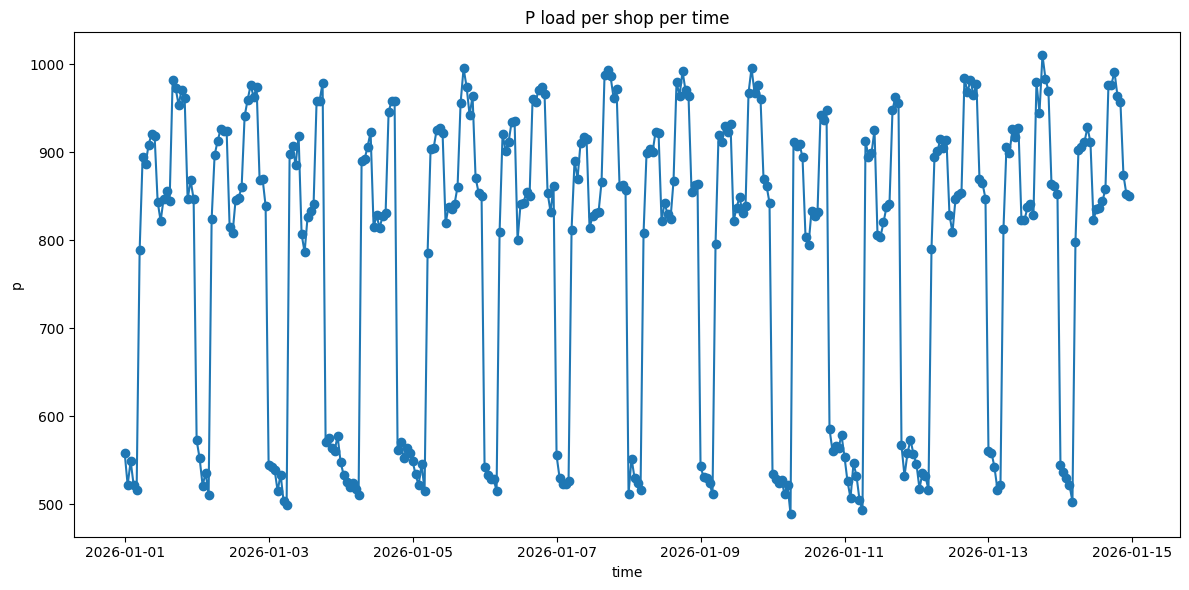

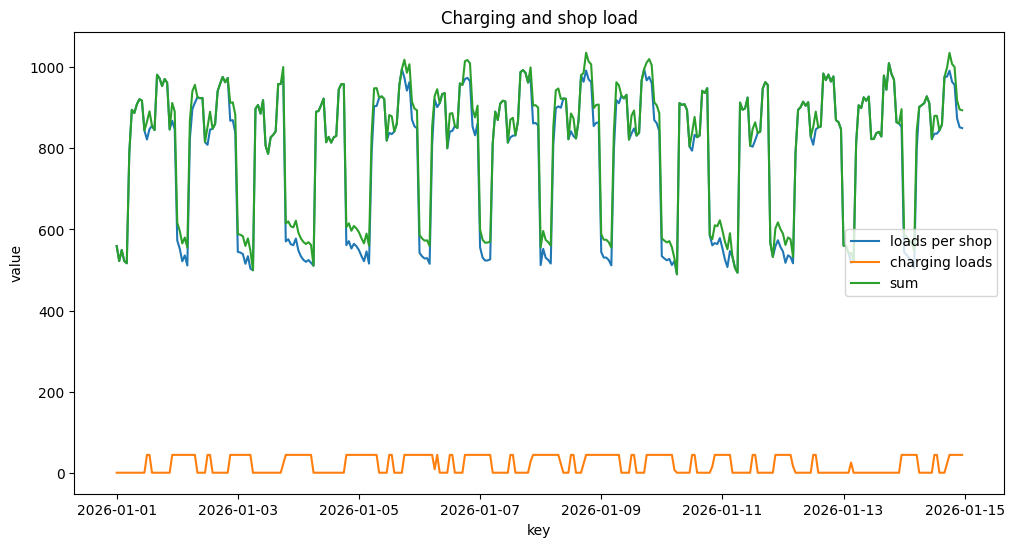


Processing schedule_ICA ...
  Testing 1 chargers ...
   ✅ Feasible with 1 chargers, cost = 64.64 €
  -> Minimum chargers required: 1


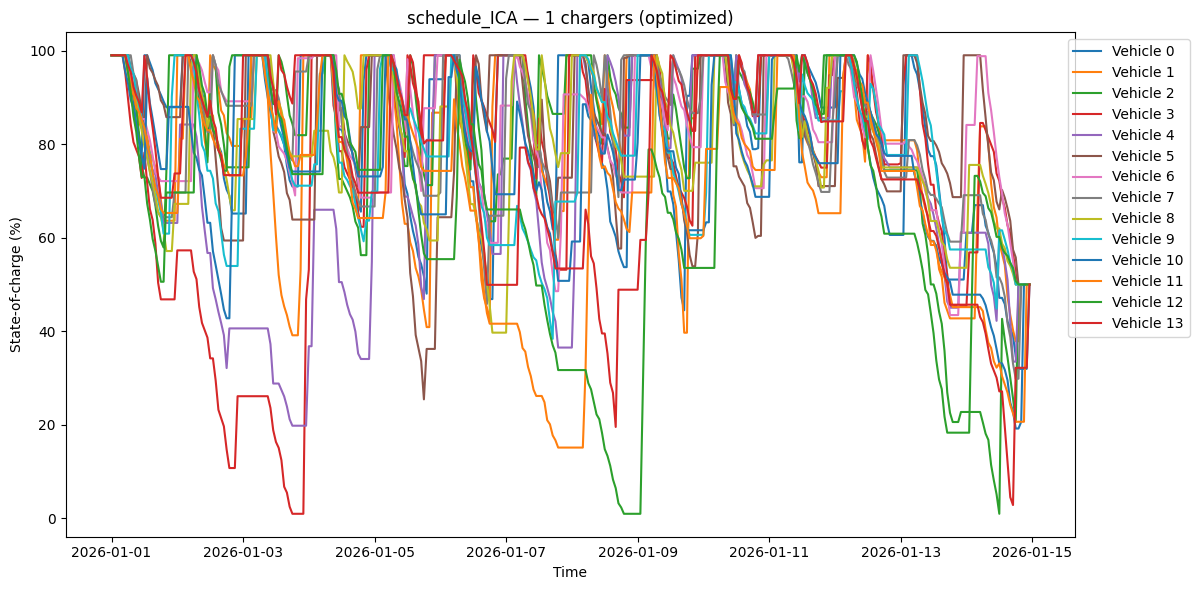

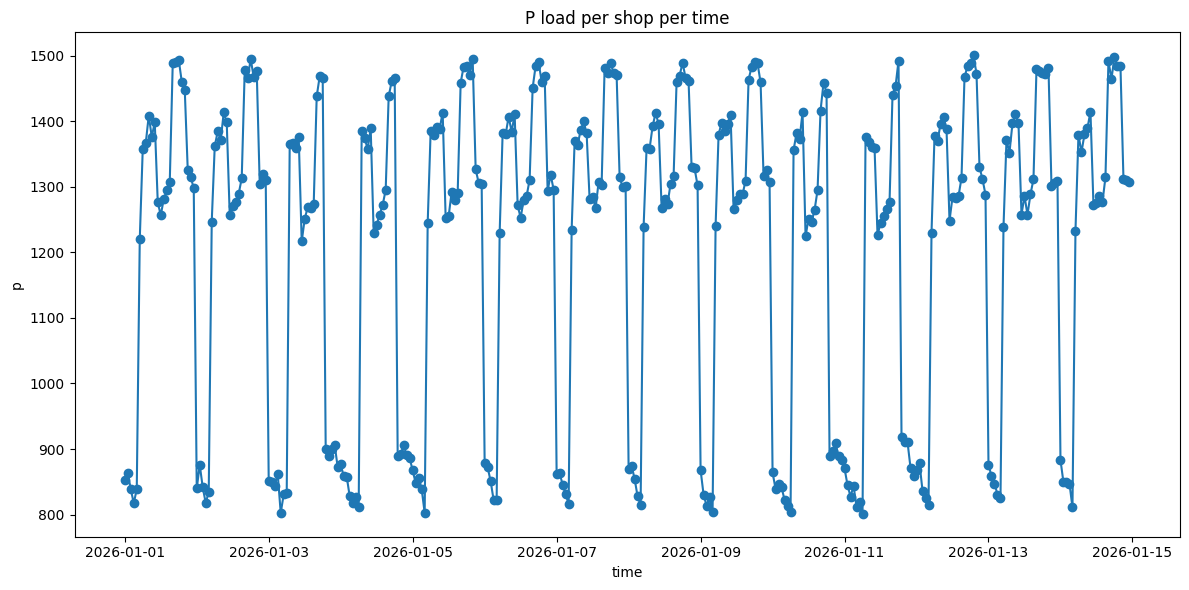

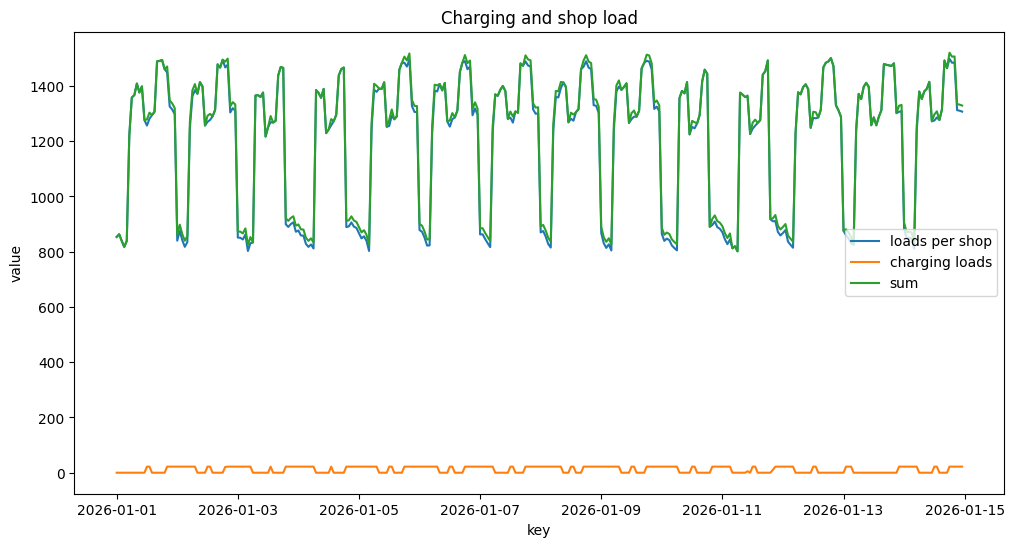


Optimization Summary:
 schedule_Airmee: 2 chargers (reason=ok)
 schedule_Postnord: 4 chargers (reason=ok)
 schedule_Mathem: 2 chargers (reason=ok)
 schedule_ICA: 1 chargers (reason=ok)

PHASE 2: NETWORK POWER FLOW SIMULATION

Running power flow simulations...
Progress: 2026-01-01 00:00:00
Progress: 2026-01-02 00:00:00
Progress: 2026-01-03 00:00:00
Progress: 2026-01-04 00:00:00
Progress: 2026-01-05 00:00:00
Progress: 2026-01-06 00:00:00
Progress: 2026-01-07 00:00:00
Progress: 2026-01-08 00:00:00
Progress: 2026-01-09 00:00:00
Progress: 2026-01-10 00:00:00
Progress: 2026-01-11 00:00:00
Progress: 2026-01-12 00:00:00
Progress: 2026-01-13 00:00:00
Progress: 2026-01-14 00:00:00

Total losses: 65.2638 MW
Peak load: 26.8322 MW at 2026-01-05 20:00:00
Average load: 25.7729 MW
Load factor: 0.9605

Lines and trafos violating limits (>100% loading):
  None

Buses violating voltage limits (1.1/0.9 pu):
  None

PHASE 3: N-1 CONTINGENCY ANALYSIS (only at worst-case timestep)
Finding worst-case timesta

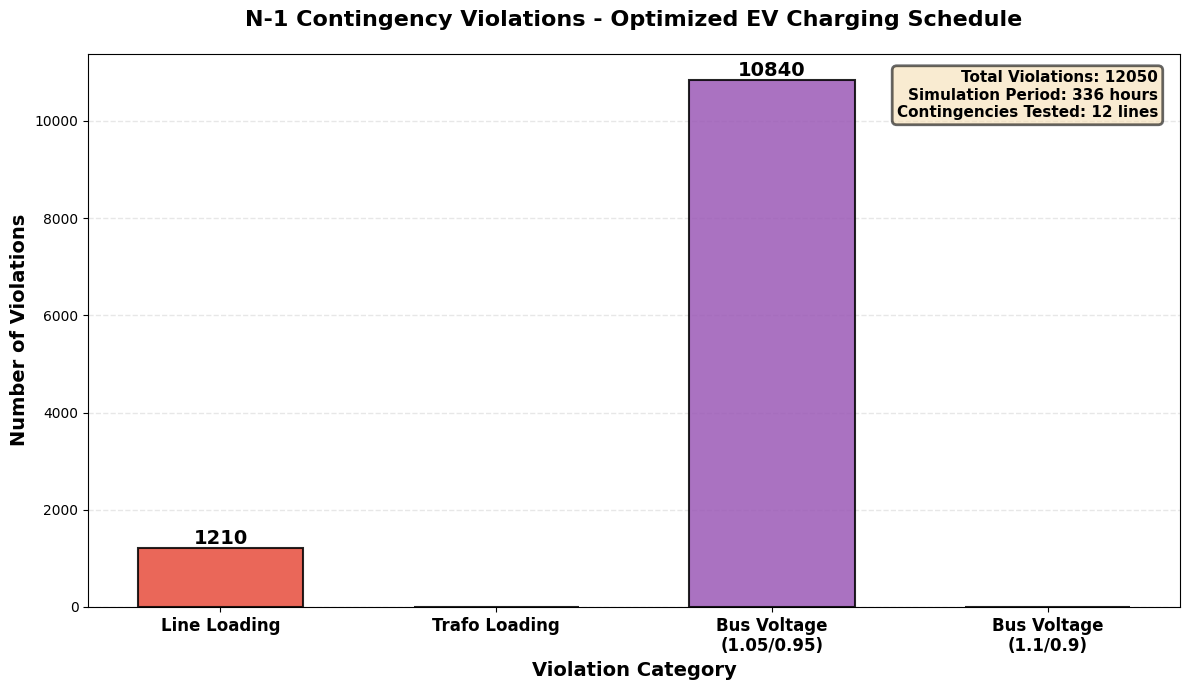


ANALYSIS COMPLETE

Total violations: 12050
Most critical violation category: Bus Voltage (1.05/0.95)
Most critical line: Line 0 (3499 violations)


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import timedelta
import math
import csv
import copy

# Pyomo imports
from pyomo.environ import (
    ConcreteModel, Var, Set, Param, Objective, Constraint, NonNegativeReals,
    Reals, SolverFactory, value, summation
)

import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top
import networkx as nx

# -------------------------
# Config / mappings
# -------------------------
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}
SOC_max_percentage = 0.99
SOC_min_percentage = 0.01
SOC_last_time_step_percentage = 0.5
FAST_AC_CAPACITY_KW = 22.0

# Load freight profiles
file_path_loads = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path_loads)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
).dt.tz_localize(None)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]

# -------------------------
# Core optimizer function
# -------------------------
def optimize_shop_energy_cost(file_path,
                              n_chargers,
                              price_series,
                              solver_name='glpk',
                              verbose=False):
    """
    Build and solve a Pyomo LP that minimizes energy cost for charging
    with a fixed number of chargers.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    df = pd.read_csv(file_path)
    if 'date' not in df.columns:
        raise ValueError("CSV must have a 'date' column with timestamps.")
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    time_index = sorted(df['date'].unique())
    T = len(time_index)
    if T < 1:
        raise ValueError("No timestamps found in file.")

    time_to_idx = {ts: idx+1 for idx, ts in enumerate(time_index)}
    idx_to_time = {idx+1: ts for idx, ts in enumerate(time_index)}

    delta_hours = {}
    for idx in range(1, T+1):
        if idx == 1:
            if T >= 2:
                dt = (idx_to_time[2] - idx_to_time[1]).total_seconds() / 3600.0
            else:
                dt = 1.0
        else:
            dt = (idx_to_time[idx] - idx_to_time[idx-1]).total_seconds() / 3600.0
        if dt <= 0:
            dt = 1.0
        delta_hours[idx] = dt

    vehicles = sorted(df['VehicleID'].unique())
    if len(vehicles) == 0:
        raise ValueError("No vehicles found in the schedule CSV.")

    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    Pmax_by_vehicle = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW)
                       for vid in vehicles}
    Cap_by_vehicle = {vid: battery_capacities.get(vehicle_types.get(vid), 48.0)
                      for vid in vehicles}

    idx_cols = ['VehicleID', 'date']
    agg = df.groupby(idx_cols).agg({
        'Consumption_kWh': 'sum',
        'Location': 'max'
    }).reset_index()

    E_drive = {(vid, t): 0.0 for vid in vehicles for t in range(1, T+1)}
    I_at_depot = {(vid, t): 0 for vid in vehicles for t in range(1, T+1)}

    for _, row in agg.iterrows():
        vid = row['VehicleID']
        ts = row['date']
        idx = time_to_idx[ts]
        E_drive[(vid, idx)] = float(row.get('Consumption_kWh', 0.0))
        I_at_depot[(vid, idx)] = 1 if int(row.get('Location', 0)) == 1 else 0

    if price_series is None:
        flat_price = 0.20
        price_by_idx = {t: flat_price for t in range(1, T+1)}
    else:
        ps = price_series.copy()
        ps.index = pd.to_datetime(ps.index, format='%d.%m.%Y %H:%M')
        price_by_idx = {}
        for idx in range(1, T+1):
            try:
                ts = idx_to_time[idx]
                price_by_idx[idx] = ps.iloc[idx-1]
            except:
                raise ValueError("error in creating price indexes")

    model = ConcreteModel()

    model.VEH = Set(initialize=vehicles, ordered=True)
    model.TIME = Set(initialize=list(range(1, T+1)), ordered=True)

    model.Cap = Param(model.VEH, initialize=Cap_by_vehicle, within=Reals)
    model.PmaxVeh = Param(model.VEH, initialize=Pmax_by_vehicle, within=Reals)
    model.Edrive = Param(model.VEH, model.TIME, initialize=E_drive, within=Reals)
    model.Avail = Param(model.VEH, model.TIME, initialize=I_at_depot, within=Reals)
    model.dt = Param(model.TIME, initialize=delta_hours, within=Reals)
    model.price = Param(model.TIME, initialize=price_by_idx, within=Reals)
    model.n_chargers = Param(initialize=int(n_chargers))
    model.P_charger = Param(initialize=float(FAST_AC_CAPACITY_KW))
    model.SOC_max_percentage = Param(initialize=SOC_max_percentage)
    model.SOC_min_percentage = Param(initialize=SOC_min_percentage)
    model.Time_steps_amount = Param(initialize=T)
    model.SOC_last_time_step_percentage = Param(initialize=SOC_last_time_step_percentage)

    model.P = Var(model.VEH, model.TIME, domain=NonNegativeReals)
    model.SOC = Var(model.VEH, model.TIME, domain=NonNegativeReals)

    def obj_rule(m):
        return sum(m.price[t] * m.P[v, t] * m.dt[t] for v in m.VEH for t in m.TIME)
    model.obj = Objective(rule=obj_rule, sense=1)

    def p_max_rule(m, v, t):
        return m.P[v, t] <= m.Avail[v, t] * m.PmaxVeh[v]
    model.p_max_con = Constraint(model.VEH, model.TIME, rule=p_max_rule)

    def charger_cap_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) <= m.n_chargers * m.P_charger
    model.charger_cap_con = Constraint(model.TIME, rule=charger_cap_rule)

    def charger_cap_rule_unique(m, v, t):
        return m.P[v, t] <= m.P_charger
    model.charger_cap_con_uniq = Constraint(model.VEH, model.TIME, rule=charger_cap_rule_unique)

    def soc_first_rule(m, v):
        t = 1
        return m.SOC[v, t] == m.Cap[v] * m.SOC_max_percentage - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_first_con = Constraint(model.VEH, rule=soc_first_rule)

    def soc_evol_rule(m, v, t):
        if t == 1:
            return Constraint.Skip
        return m.SOC[v, t] == m.SOC[v, t-1] - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_evol_con = Constraint(model.VEH, model.TIME, rule=soc_evol_rule)

    def soc_ub_rule(m, v, t):
        return m.SOC[v, t] <= m.Cap[v] * m.SOC_max_percentage
    model.soc_ub_con = Constraint(model.VEH, model.TIME, rule=soc_ub_rule)

    def soc_lb_rule(m, v, t):
        return m.SOC[v, t] >= m.Cap[v] * m.SOC_min_percentage
    model.soc_lb_con = Constraint(model.VEH, model.TIME, rule=soc_lb_rule)

    def soc_end_rule(m, v):
        t = m.Time_steps_amount
        return m.SOC[v, t] == m.Cap[v] * m.SOC_last_time_step_percentage
    model.soc_end_con = Constraint(model.VEH, rule=soc_end_rule)

    solver = None
    solver_try_order = [solver_name, 'cbc', 'glpk'] if solver_name != 'glpk' else ['glpk', 'cbc']
    solver_available = False
    last_solver_err = None
    for sname in solver_try_order:
        try:
            solver = SolverFactory(sname)
            if solver is None:
                continue
            res = solver.solve(model, tee=verbose)
            solver_available = True
            break
        except Exception as e:
            last_solver_err = e
            solver = None
            continue

    if not solver_available:
        raise RuntimeError(f"No solver available/working. Tried {solver_try_order}. "
                           f"Last error: {last_solver_err}")

    obj_val = value(model.obj) / 1000

    P_sol = {}
    P_per_time = {}
    SOC_traces = {v: [] for v in vehicles}
    SOC_traces_percentage = {v: [] for v in vehicles}
    for t in model.TIME:
        all_P = 0.0
        for v in model.VEH:
            P_sol[(v, idx_to_time[t])] = float(value(model.P[v, t]))
            all_P += float(value(model.P[v, t]))
        P_per_time[idx_to_time[t]] = all_P

    for v in vehicles:
        for t in model.TIME:
            SOC_traces[v].append(float(value(model.SOC[v, t])))
            SOC_traces_percentage[v].append(float(value(model.SOC[v, t] / model.Cap[v])))

    n_vehicles = len(vehicles)
    if n_chargers > n_vehicles:
        raise RuntimeError(f"No feasible solution found, number of chargers {n_chargers} would be higher than number of vehicles {n_vehicles}")

    result = {
        'status': str(res.solver.termination_condition) if hasattr(res, 'solver') else 'unknown',
        'objective': obj_val,
        'P': P_sol,
        'P_time': P_per_time,
        'SOC': SOC_traces,
        'time_index': [idx_to_time[t] for t in model.TIME],
        'n_chargers': int(n_chargers),
        'solver': solver,
        'SOC_percentage': SOC_traces_percentage
    }

    return result

# -------------------------
# Plotting helper
# -------------------------
def plot_soc_from_result(result, shop, title=None, save_fig=False, out_path=None):
    time = result['time_index']
    soc_percentage = result['SOC_percentage']
    p_shop = result['P_time']

    plt.figure(figsize=(12, 6))
    for vid, series in soc_percentage.items():
        series_pct = [s * 100.0 for s in series]
        plt.plot(time, series_pct, label=f"Vehicle {vid}")

    plt.xlabel("Time")
    plt.ylabel("State-of-charge (%)")
    if title is None:
        title = f"SOC over time — {result.get('n_chargers', '?')} chargers"
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        if out_path is None:
            out_path = Path("soc_plot.png")
        plt.savefig(out_path, dpi=150)
        print("Saved figure to", out_path)
    plt.show()

    shop_name = shop.split("_")[1]
    shop_loads = load_profile[shop_name]
    shop_loads = shop_loads.to_dict()

    plt.figure(figsize=(12, 6))
    xs, ys = zip(*sorted(shop_loads.items()))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("time")
    plt.ylabel("p")
    plt.title("P load per shop per time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    x = sorted(shop_loads.keys())
    y1 = [shop_loads[k] for k in x]
    y2 = [p_shop[k] for k in x]
    y3 = [p_shop[k] + shop_loads[k] for k in x]

    plt.plot(x, y1, label="loads per shop")
    plt.plot(x, y2, label="charging loads")
    plt.plot(x, y3, label="sum")
    plt.legend()
    plt.xlabel("key")
    plt.ylabel("value")
    plt.title("Charging and shop load")
    plt.show()

def open_price_file():
    prices = {}
    date_format = '%d.%m.%Y %H:%M'

    with open("Prices.csv", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader, None)
        for row in reader:
            from_time = row[0].split(" - ")[0]
            prices[from_time] = float(row[1])
    prices_pd = pd.Series(prices)
    return prices_pd

# -------------------------
# OPTIMIZATION PHASE
# -------------------------
shop_optimized_charging_schedules = {}

base_path = Path(os.getcwd()).parent / "data" / "Output"
shops_schedule = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

results = {}
MAX_CHARGERS_TO_TEST = 29

print("="*60)
print("PHASE 1: EV CHARGING OPTIMIZATION")
print("="*60)

for shop in shops_schedule:
    shop_folder = base_path / shop
    file = shop_folder / f"{shop}.csv"
    if not file.exists():
        print(f"[WARN] file not found: {file}")
        results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
        continue

    print(f"\nProcessing {shop} ...")

    found = False
    best_trace = None
    best_cost = None
    prices = open_price_file()
    for n_ch in range(1, MAX_CHARGERS_TO_TEST, 1):
        print(f"  Testing {n_ch} chargers ...")
        try:
            res = optimize_shop_energy_cost(file, n_chargers=n_ch, price_series=prices, solver_name='glpk', verbose=False)
        except Exception as e:
            print(f"   Solver failed for {n_ch} chargers: {e}")
            continue

        feasible = all(all(val >= -1e-6 for val in soc_list) for soc_list in res['SOC'].values())

        if feasible:
            print(f"   ✅ Feasible with {n_ch} chargers, cost = {res['objective']:.2f} €")
            found = True
            best_trace = res
            best_cost = res['objective']
            best_trace_percentage = res['SOC_percentage']
            shop_name = shop.replace("schedule_", "")
            shop_optimized_charging_schedules[shop_name] = res["P_time"]
            break
        else:
            print(f"   ❌ Infeasible with {n_ch} chargers (battery empty at some point)")

    if found:
        print(f"  -> Minimum chargers required: {n_ch}")
        results[shop] = {
            'min_chargers': n_ch,
            'objective': best_cost,
            'trace': best_trace,
            'trace_percentage': best_trace['SOC_percentage']
        }
        df = pd.read_csv(file)
        vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

        plot_soc_from_result(best_trace, shop, title=f"{shop} — {n_ch} chargers (optimized)", save_fig=False)
    else:
        print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
        results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}

print("\nOptimization Summary:")
for shop, info in results.items():
    print(f" {shop}: {info.get('min_chargers')} chargers (reason={info.get('reason','ok')})")

# -------------------------
# PHASE 2: NETWORK SIMULATION
# -------------------------
print("\n" + "="*60)
print("PHASE 2: NETWORK POWER FLOW SIMULATION")
print("="*60)

# Create network
net0 = nw.create_cigre_network_mv(with_der=False)
net0.switch["closed"] = True
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0
base_loads = net0.load['p_mw'].copy()

# Shop placements
shop_to_bus = {
    "ICA": 13,
    "Mathem": 6,
    "Postnord": 10,
    "Airmee": 6,
}

# Function to create network with shop loads
def create_network_with_shops(net_base, shop_mapping, timestamp, charging_loads):
    net = copy.deepcopy(net_base)
    net.load['p_mw'] = base_loads.copy()

    for shop, bus in shop_mapping.items():
        charging_load_shop = charging_loads[shop]
        if bus is not None:
            existing_loads = net.load[net.load.bus == bus]

            if not existing_loads.empty:
                load_idx = existing_loads.index[0]
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_freight
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_charging
            else:
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                add_mw = add_mw_charging + add_mw_freight
                pp.create_load(net, bus=bus, p_mw=add_mw, q_mvar=0)

    return net

# Run final simulation with all shops
print("\nRunning power flow simulations...")

line_indices = list(net0.line.index)
col_names = [f"line_{i}" for i in line_indices]
res_lines_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)
res_lines_final_loading = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

trafo_indices = list(net0.trafo.index)
col_names = [f"trafo_{i}" for i in trafo_indices]
res_trafo_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)
res_trafo_final_loading = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

bus_indices = list(net0.bus.index)
col_names = [f"bus_{i}" for i in bus_indices]
res_bus_final_voltage = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

peak_load = 0.0
peak_load_ts = None
sum_all_loads = 0.0
all_losses = 0.0
all_nets = {}

for ts_idx, ts in enumerate(load_profile.index):
    if ts_idx % 24 == 0:
        print(f"Progress: {ts}")

    net_final = create_network_with_shops(net0, shop_to_bus, ts, shop_optimized_charging_schedules)
    all_nets[ts] = net_final

    try:
        pp.runpp(net_final, calculate_voltage_angles=False)
        line_loading = net_final.res_line.loading_percent
        line_losses = net_final.res_line.pl_mw
        trafo_loading = net_final.res_trafo.loading_percent
        bus_voltage = net_final.res_bus.vm_pu

        for li in line_indices:
            res_lines_final_losses.at[ts, f"line_{li}"] = line_losses.at[li]
            all_losses += line_losses.at[li]
            res_lines_final_loading.at[ts, f"line_{li}"] = line_loading.at[li]

        trafo_losses = net_final.res_trafo.pl_mw
        for tr in trafo_indices:
            res_trafo_final_losses.at[ts, f"trafo_{tr}"] = trafo_losses.at[tr]
            all_losses += trafo_losses.at[tr]
            res_trafo_final_loading.at[ts, f"trafo_{tr}"] = trafo_loading.at[tr]

        for bs in bus_indices:
            res_bus_final_voltage.at[ts, f"bus_{bs}"] = bus_voltage.at[bs]

        all_load_ts = net_final.load['p_mw'].sum()
        if all_load_ts > peak_load:
            peak_load = all_load_ts
            peak_load_ts = ts

        sum_all_loads += all_load_ts

    except Exception as e:
        print(f"Power flow failed at {ts}: {e}")

print(f"\nTotal losses: {all_losses:.4f} MW")
print(f"Peak load: {peak_load:.4f} MW at {peak_load_ts}")
average_load = sum_all_loads / 336
print(f"Average load: {average_load:.4f} MW")
load_factor = average_load / peak_load
print(f"Load factor: {load_factor:.4f}")

print("\nLines and trafos violating limits (>100% loading):")
violations_found = False
for ts_idx, ts in enumerate(load_profile.index):
    for li in line_indices:
        line_loading = res_lines_final_loading.at[ts, f"line_{li}"]
        if line_loading > 100:
            print(f"  line_{li}: {line_loading:.2f}% at {ts}")
            violations_found = True

for ts_idx, ts in enumerate(load_profile.index):
    for tr in trafo_indices:
        trafo_loading = res_trafo_final_loading.at[ts, f"trafo_{tr}"]
        if trafo_loading > 100:
            print(f"  trafo_{tr}: {trafo_loading:.2f}% at {ts}")
            violations_found = True

if not violations_found:
    print("  None")

print("\nBuses violating voltage limits (1.1/0.9 pu):")
violations_found = False
for ts_idx, ts in enumerate(load_profile.index):
    for bs in bus_indices:
        bus_voltage = res_bus_final_voltage.at[ts, f"bus_{bs}"]
        if bus_voltage > 1.1 or bus_voltage < 0.9:
            print(f"  bus_{bs}: {bus_voltage:.4f} pu at {ts}")
            violations_found = True

if not violations_found:
    print("  None")
# -------------------------
# PHASE 3: N-1 CONTINGENCY ANALYSIS (run only at worst-case)
# -------------------------
print("\n" + "="*60)
print("PHASE 3: N-1 CONTINGENCY ANALYSIS (only at worst-case timestep)")
print("="*60)

# --- 1. Identify the worst-case time step based on line loading ---
print("Finding worst-case timestamp...")
all_loadings = []

for ts_idx, ts in enumerate(load_profile.index):
    net = copy.deepcopy(all_nets[ts])
    try:
        pp.runpp(net)
        all_loadings.append(net.res_line.loading_percent.max())
    except:
        all_loadings.append(np.nan)

worst_idx = int(np.nanargmax(all_loadings))
worst_ts = load_profile.index[worst_idx]
worst_loading = np.nanmax(all_loadings)
print(f"  >> Worst-case line loading: {worst_loading:.2f}% at {worst_ts}")

# --- 2. Prepare network snapshot for that timestamp ---
net = copy.deepcopy(all_nets[worst_ts])
print(f"Running N-1 contingency only for this timestamp...")

# --- 3. Run single-time-step N-1 analysis ---
line_indices = list(net.line.index)
violation_rows = []

for out_line in line_indices:
    net.line.at[out_line, "in_service"] = False
    net.switch["closed"] = True

    try:
        pp.runpp(net, calculate_voltage_angles=False)

        # Record any overloads or voltage violations
        for line_id, loading in net.res_line.loading_percent.items():
            if loading > 100:
                violation_rows.append(("line", int(line_id), float(loading)))

        for trafo_id, loading in net.res_trafo.loading_percent.items():
            if loading > 100:
                violation_rows.append(("trafo", int(trafo_id), float(loading)))

        for bus_id, v in net.res_bus.vm_pu.items():
            if (v > 1.05) or (v < 0.95):
                violation_rows.append(("bus(1.05/0.95)", int(bus_id), float(v)))
            if (v > 1.1) or (v < 0.9):
                violation_rows.append(("bus(1.1/0.9)", int(bus_id), float(v)))

    except Exception as e:
        print(f"  Warning: N-1 power flow failed when removing line {out_line}: {e}")

    # Restore the line
    net.line.at[out_line, "in_service"] = True

# --- 4. Summarize results ---
print(f"\n  Total recorded violations: {len(violation_rows)}")

if violation_rows:
    df_viol = pd.DataFrame(violation_rows, columns=["category", "element_id", "value"])
    print("\nTop 10 violations:")
    print(df_viol.groupby("category").size().sort_values(ascending=False).head(10))
    df_viol.to_csv("n1_violations_worstcase.csv", index=False)
    print("Saved detailed results to n1_violations_worstcase.csv")
else:
    print("✅ No violations detected at worst-case timestep.")

# -------------------------
# VISUALIZATION
# -------------------------
fig, ax = plt.subplots(figsize=(12, 7))

categories = list(violation_summary.keys())
counts = list(violation_summary.values())
colors = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db']

x_pos = np.arange(len(categories))
bars = ax.bar(x_pos, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85, width=0.6)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(count)}',
               ha='center', va='bottom',
               fontsize=14, fontweight='bold')

ax.set_ylabel('Number of Violations', fontsize=14, fontweight='bold')
ax.set_xlabel('Violation Category', fontsize=14, fontweight='bold')
ax.set_title('N-1 Contingency Violations - Optimized EV Charging Schedule',
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Add summary statistics box
total_violations = sum(counts)
textstr = f'Total Violations: {total_violations}\nSimulation Period: {len(load_profile)} hours\nContingencies Tested: 12 lines'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6, edgecolor='black', linewidth=2)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nTotal violations: {total_violations}")
print(f"Most critical violation category: {max(violation_summary.items(), key=lambda x: x[1])[0].replace(chr(10), ' ')}")

if critical_lines:
    most_critical_line = max(critical_lines.items(), key=lambda x: x[1])
    print(f"Most critical line: Line {most_critical_line[0]} ({most_critical_line[1]} violations)")
else:
    print("No critical lines identified")